# Evidencia 1 - Fase 2 - Parte B: Implementación usando NLP

Andrea Doce Murillo - A01799931
Sandra Paulina Herrera Rebolledo - A01798452
Ian Alexei Mtz. Armendáriz - A01753288

# 1. Imports

In [4]:
#Instalación de las librerías necesarias
%pip install gensim nltk scikit-learn matplotlib pandas

#Librerias para el procesamiento de texto, modelado de Word2Vec, reducción de dimensionalidad y visualización
import re #expresiones regulares para limpieza de texto
import pandas as pd #para manejo de datos
import nltk #para procesamiento de lenguaje natural
from nltk.corpus import stopwords #para eliminar palabras vacías
from gensim.models import Word2Vec #para modelar Word2Vec
from sklearn.decomposition import PCA #para reducción de dimensionalidad
from matplotlib import pyplot as plt #para visualización

nltk.download("stopwords") #descarga de stopwords para español


Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sandraherrera/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 2. Convertir CSV a TXT limpio


In [5]:
# LIMPIEZA Y COMBINACIÓN DE DOS CSV + GENERACIÓN DEL TXT
from sklearn.model_selection import train_test_split
import pandas as pd
import re

csv_path_1 = "tweets1.csv"
csv_path_2 = "tweets2.csv"

txt_path = "tweets_limpios.txt"

def limpiar_tweet(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"#", " ", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def cargar_csv(path):
    df = pd.read_csv(path)

    if "tweet_text" not in df.columns:
        raise ValueError(f"No se encontró tweet_text en {path}")

    if "class" not in df.columns:
        raise ValueError(f"No se encontró class en {path}")

    df = df[["tweet_text","class"]].copy()
    df["tweet_text"] = df["tweet_text"].apply(limpiar_tweet)
    df = df.dropna(subset=["tweet_text"])
    df = df[df["tweet_text"] != ""]
    return df

df_1 = cargar_csv(csv_path_1)
df_2 = cargar_csv(csv_path_2)

df_csv = pd.concat([df_1, df_2], ignore_index=True)

print("Total de tweets antes de eliminar duplicados:", len(df_csv))

df_csv = df_csv.drop_duplicates(subset=["tweet_text"]).reset_index(drop=True)

print("Total de tweets después de eliminar duplicados:", len(df_csv))

print("Valores únicos en class:", df_csv["class"].unique())

df_csv["class"] = df_csv["class"].map({
    "anorexia": 1,
    "control": 0
})

train_df, val_df = train_test_split(
    df_csv,
    test_size=0.2,
    stratify=df_csv["class"],
    random_state=42
)

print("\nDistribución original:")
print(df_csv["class"].value_counts(normalize=True))

print("\nTrain:")
print(train_df["class"].value_counts(normalize=True))

print("\nValidation:")
print(val_df["class"].value_counts(normalize=True))

df_csv = train_df.copy()

df_csv["tweet_text"].to_csv(
    txt_path,
    index=False,
    header=False
)

print(f"Archivo TXT generado correctamente: {txt_path}")
print(f"Tweets guardados: {len(df_csv)}")

df_csv.head(10)



Total de tweets antes de eliminar duplicados: 500
Total de tweets después de eliminar duplicados: 374
Valores únicos en class: <StringArray>
['anorexia', 'control']
Length: 2, dtype: str

Distribución original:
class
1    0.537433
0    0.462567
Name: proportion, dtype: float64

Train:
class
1    0.538462
0    0.461538
Name: proportion, dtype: float64

Validation:
class
1    0.533333
0    0.466667
Name: proportion, dtype: float64
Archivo TXT generado correctamente: tweets_limpios.txt
Tweets guardados: 299


,tweet_text,class
327,thinspo y las inspiraciones que encontramos en...,1
90,mis amigas no me ignoran no mienten me aconsej...,1
353,hoy cenamos tostadas de aguacate con huevo poc...,0
141,las mejores opciones de snacks para los pequeñ...,0
117,día de ayuno y hoy si que los mareos han hecho...,1
32,abastero corte de vacuno chileno al horno en c...,0
263,er día desayuno una manzana almuerzo litro de ...,1
61,comer hasta vomitar asu,1
233,un año que cerramos cargado de buenos deseos y...,0
119,piensa antes de comer no comas cuando te distr...,1


# 3. Cargar el archivo TXT limpio

In [6]:
#se carga el archivo TXT generado para verificar su contenido
file_path = "tweets_limpios.txt"

# Función para corregir mojibake (caracteres extraños) en el texto
def fix_mojibake(text):
    try:
        return text.encode("cp1252", errors="ignore").decode("utf-8", errors="ignore")
    except Exception:
        return text

# al tener el archivo TXT, se lee su contenido para verificar que se haya guardado correctamente y corregir posibles mojibake
with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

# se corrige mojibake en el texto completo antes de procesarlo
raw_text = fix_mojibake(raw_text)
tweets = [line.strip() for line in raw_text.split("\n") if line.strip()]

# Se muestra una vista previa de los primeros tweets para verificar que se hayan guardado correctamente
df = pd.DataFrame({"tweet_original": tweets})
df.head(10)


,tweet_original
0,thinspo y las inspiraciones que encontramos en...
1,mis amigas no me ignoran no mienten me aconsej...
2,hoy cenamos tostadas de aguacate con huevo poc...
3,las mejores opciones de snacks para los pequeo...
4,da de ayuno y hoy si que los mareos han hecho ...
5,abastero corte de vacuno chileno al horno en c...
6,er da desayuno una manzana almuerzo litro de a...
7,comer hasta vomitar asu
8,un ao que cerramos cargado de buenos deseos y ...
9,piensa antes de comer no comas cuando te distr...


# 4. Limpieza y preprocesamiento

In [7]:
# Preprocesamiento de texto: normalización, tokenización y eliminación de stopwords
stop_words = set(stopwords.words("spanish"))

# Se agregan stopwords personalizadas que son comunes en tweets
custom_stopwords = {
    "http", "https", "co", "rt", "via", "mas", "aqui", "hoy", "dia", "dias",
    "hacer", "quiero", "tener", "ser", "voy"
}
stop_words = stop_words.union(custom_stopwords)

# Función para normalizar el texto: convertir a minúsculas, eliminar links, menciones, símbolos, números y caracteres no alfabéticos
def normalizar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)          # quitar links
    texto = re.sub(r"@\w+", " ", texto)                    # quitar menciones
    texto = re.sub(r"#", " ", texto)                        # quitar símbolo #, dejar solo palabra
    texto = re.sub(r"\d+", " ", texto)                      # quitar números
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)          # conservar letras españolas
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Función para tokenizar el texto: dividir en palabras, eliminar stopwords y tokens muy cortos
def tokenizar(texto):
    texto = normalizar_texto(texto)
    tokens = texto.split()
    tokens = [t for t in tokens if len(t) > 2 and t not in stop_words]
    return tokens

# Se aplica la tokenización a la columna de tweets originales y se guarda en una nueva columna "tokens"
df["tokens"] = df["tweet_original"].apply(tokenizar)

# Se muestra una vista previa de los tweets originales junto con sus tokens para verificar que el preprocesamiento se haya aplicado correctamente
data = df["tokens"].tolist()
data = [tokens for tokens in data if len(tokens) > 1]

#se imprime una vista previa de los tokens generados para los primeros tweets
print(data[:5])


[['thinspo', 'inspiraciones', 'encontramos', 'internet', 'fomentando', 'extrema', 'delgadez', 'anorexia', 'bulimia'], ['amigas', 'ignoran', 'mienten', 'aconsejan', 'recuerdan', 'errores', 'metas', 'quieren', 'princesa'], ['cenamos', 'tostadas', 'aguacate', 'huevo', 'pochado', 'foodie', 'foodporn', 'yummy', 'healthyfood', 'lifestyle', 'bloggerspain', 'aguacate', 'instamood'], ['mejores', 'opciones', 'snacks', 'pequeos', 'casa', 'cocinafacil', 'comersano', 'healthyfood', 'foodporn', 'food', 'foodie', 'foodgasm', 'elhornodelucas', 'lovecooking', 'instafood', 'recetasrapidas', 'recipe', 'recipes', 'recetas', 'comidamexicana', 'mexicanfood'], ['ayuno', 'mareos', 'hecho', 'estragos', 'rexybill']]


# 5. Filtrar tweets relacionados directamente con anorexia/TCA

In [8]:
# Se define un conjunto de palabras clave relacionadas con anorexia y trastornos alimenticios para identificar tweets que puedan estar relacionados con estos temas
keywords_tca = {
    "anorexia", "anorexica", "anorexic", "anoreccia", "bulimia", "bulymia",
    "tca", "trastornosalimenticios", "ana", "mia", "proana", "promia",
    "thinspo", "thinspiration", "ayunar", "vomitar", "vomito", "delgada",
    "gorda", "peso", "calorias", "hambre", "laxantes", "noteat"
}

# Se verifica si cada tweet contiene alguna de las palabras clave relacionadas con anorexia/TCA y se crea una nueva columna "es_tca" con el resultado booleano
def contiene_keyword(tokens):
    return any(token in keywords_tca for token in tokens)

# con ello se filtran los tweets que contienen alguna de las palabras clave relacionadas con anorexia/TCA y se crea un nuevo DataFrame df_tca con solo esos tweets
df["es_tca"] = df["tokens"].apply(contiene_keyword)
df_tca = df[df["es_tca"]].copy()

# Se muestra la cantidad de tweets relacionados con anorexia/TCA y una vista previa de los primeros tweets originales junto con sus tokens para verificar que se hayan identificado correctamente
data_tca = df_tca["tokens"].tolist()
data_tca = [tokens for tokens in data_tca if len(tokens) > 1]

#se imprime la cantidad de tweets relacionados con anorexia/TCA y una vista previa de los primeros tweets originales junto con sus tokens para verificar que se hayan identificado correctamente
print("Tweets relacionados con anorexia/TCA:", len(data_tca))
df_tca[["tweet_original", "tokens"]].head(10) #se muestra una vista previa de los tweets relacionados con anorexia/TCA para verificar que se hayan identificado correctamente


Tweets relacionados con anorexia/TCA: 104


,tweet_original,tokens
0,thinspo y las inspiraciones que encontramos en...,"[thinspo, inspiraciones, encontramos, internet..."
7,comer hasta vomitar asu,"[comer, vomitar, asu]"
8,un ao que cerramos cargado de buenos deseos y ...,"[cerramos, cargado, buenos, deseos, grandes, r..."
10,esas piernas son lo que mas deseo en esta vida...,"[piernas, deseo, vida, todavia, vida, thinspo,..."
12,yo para no contar calorias no como nada,"[contar, calorias]"
15,no es hambre son aplausos del estmago,"[hambre, aplausos, estmago]"
16,denuncia estas pgs denuncia las empresas que l...,"[denuncia, pgs, denuncia, empresas, mantienen,..."
19,lo que me alimenta me destruye anorexia bulimia,"[alimenta, destruye, anorexia, bulimia]"
27,nunca llegar a mi peso de nacimiento,"[nunca, llegar, peso, nacimiento]"
28,estoy a favor de la anorexia y la bulimia ya q...,"[favor, anorexia, bulimia, cumple, sueos, aunq..."


# 6. Entrenar modelo Word2Vec

In [9]:
# Para el modelado de Word2Vec, se utiliza el corpus de tweets relacionados con anorexia/TCA si hay suficientes datos (al menos 10 tweets), de lo contrario se utiliza el corpus completo de tweets para entrenar el modelo
corpus = data_tca if len(data_tca) >= 10 else data

# Este modelo ayuda a aprender representaciones vectoriales de palabras basadas en su contexto dentro de los tweets, esto sirve para el análisis de sentimientos, clasificación o detección de temas relacionados con anorexia y trastornos alimenticios
model = Word2Vec(
    sentences=corpus,
    vector_size=50,   # tamaño del vector de cada palabra
    sg=1,             # 1 = Skip-gram; 0 = CBOW
    window=5,         # tamaño de la ventana de contexto
    min_count=1,      # frecuencia mínima de palabras
    workers=4,        # número de trabajadores para el entrenamiento
    epochs=200,       # número de épocas de entrenamiento
    seed=42           # para reproducibilidad 
)

# se imprime una vista previa de las primeras palabras del vocabulario aprendido por el modelo Word2Vec para verificar que se hayan entrenado correctamente
print(model.wv.index_to_key[:30])


['anorexia', 'bulimia', 'proana', 'promia', 'ana', 'mia', 'gorda', 'peso', 'tca', 'hambre', 'thinspo', 'vomitar', 'bulimic', 'anorexic', 'bajar', 'vida', 'comer', 'vez', 'bulimicgirl', 'thinspiration', 'morir', 'comida', 'siempre', 'necesito', 'ayuno', 'anorexiaeetclub', 'cuerpo', 'puedo', 'deseo', 'alguien']


# 7. Vector de una palabra

In [10]:
palabra = "anorexia" # se verifica si la palabra "anorexia" está en el vocabulario del modelo y se imprime su vector de embedding y su tamaño, esto para verificar que el modelo haya aprendido una representación para esta palabra clave relacionada con el tema de anorexia/TCA

# se verifica si la palabra "anorexia" está en el vocabulario del modelo y se imprime su vector de embedding y su tamaño, esto para verificar que el modelo haya aprendido una representación para esta palabra clave relacionada con el tema de anorexia/TCA
if palabra in model.wv:
    embedding = model.wv[palabra]
    print(f"Vector para '{palabra}':")
    print(embedding)
    print("Tamaño del vector:", len(embedding))
else:
    print(f"La palabra '{palabra}' no aparece en el vocabulario.")


Vector para 'anorexia':
[-0.3594535  -0.5000622  -0.4145561  -0.06608963 -0.32073984  0.3746213
 -0.48705202 -0.31456816  0.01492563  0.32544705 -0.16290179  0.55493355
 -0.13434665  0.45788366  0.26512226  0.2617269   0.3828172  -0.7785639
 -0.13297895 -0.3182762   0.03045336 -0.03728973 -0.04891171  0.44158468
  0.6086474   0.24339005 -0.2337925   0.1972568   0.0964243  -0.29100543
  0.13742189 -0.77402085 -0.6271421  -0.17145891  0.00582057 -0.20395212
  0.28319007  0.14826071  0.22903706  0.17421868 -0.11977094 -0.03410282
  0.48755643  0.0012706   0.2470852   0.4981518   0.06904232  0.38594228
  0.33050832 -0.20900753]
Tamaño del vector: 50


# 8. Palabras similares

In [11]:
# se define una lista de palabras para consultar sus palabras similares en el espacio de embedding aprendido por el modelo Word2Vec, esto para verificar que el modelo haya aprendido relaciones semánticas entre estas palabras clave 
palabras_consulta = ["anorexia", "bulimia", "tca", "delgada", "peso", "comer", "vomitar", "hambre"]

# se consulta el modelo Word2Vec para cada palabra en la lista de palabras_consulta y se imprimen las palabras más similares junto con sus puntuaciones de similitud
for palabra in palabras_consulta:
    if palabra in model.wv:
        print(f"\nPalabras similares a '{palabra}':")
        similares = model.wv.most_similar(palabra, topn=5)
        for similar, score in similares:
            print(f"{similar:15s} -> {score:.4f}")
    else:
        print(f"\n'{palabra}' no está en el vocabulario.")



Palabras similares a 'anorexia':
bulimia         -> 0.8187
alimenta        -> 0.7168
destruye        -> 0.7111
elche           -> 0.6909
dios            -> 0.6760

Palabras similares a 'bulimia':
anorexia        -> 0.8187
alimenta        -> 0.8149
destruye        -> 0.8121
dios            -> 0.7793
bendiga         -> 0.7631

Palabras similares a 'tca':
eatingdisorder  -> 0.8856
estilo          -> 0.8738
anorexiarecovery -> 0.8522
anorexiaeetclub -> 0.8509
trastornosalimenticios -> 0.8387

Palabras similares a 'delgada':
espero          -> 0.9687
tengoundeseoyes -> 0.9656
sinnimo         -> 0.9548
joven           -> 0.9502
determinado     -> 0.9428

Palabras similares a 'peso':
ideal           -> 0.8826
queriendo       -> 0.8767
amor            -> 0.8255
nacimiento      -> 0.8202
tabla           -> 0.8189

Palabras similares a 'comer':
dormir          -> 0.9213
nites           -> 0.9115
asu             -> 0.8436
cuanto          -> 0.8413
casa            -> 0.8388

Palabras similares a 

# 9. Visualización con PCA

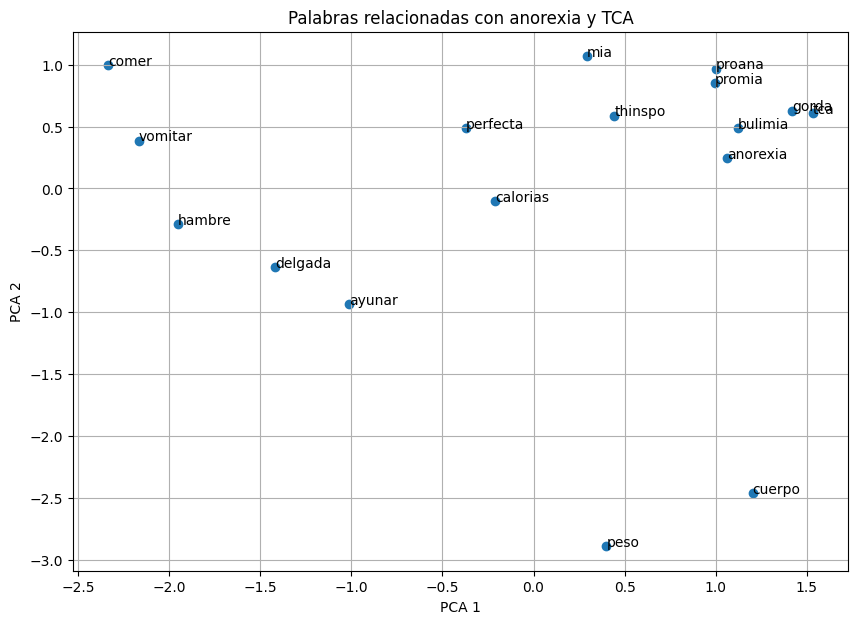

In [12]:
#en esta sección se define una función para visualizar las palabras en el espacio de embedding utilizando PCA para reducir la dimensionalidad a 2D
def visualizar_palabras(palabras, titulo="Visualización Word2Vec"):
    palabras_presentes = [p for p in palabras if p in model.wv]
    
    if len(palabras_presentes) < 2: # se verifica que haya al menos 2 palabras presentes en el vocabulario para poder graficar
        print("No hay suficientes palabras presentes en el vocabulario para graficar.")
        return
    
    X = model.wv[palabras_presentes] # se obtiene el vector de embedding para cada palabra presente en la lista de palabras
    pca = PCA(n_components=2) # se inicializa PCA para reducir a 2 dimensiones
    result = pca.fit_transform(X) # se aplica PCA para reducir la dimensionalidad de los vectores de embedding a 2D para visualización
    
    plt.figure(figsize=(10, 7)) # se crea una figura para la visualización
    plt.scatter(result[:, 0], result[:, 1])
    
    for i, word in enumerate(palabras_presentes):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    
    plt.title(titulo)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.show()

palabras_tca = [
    "anorexia", "bulimia", "tca", "mia", "proana", "promia",
    "thinspo", "delgada", "gorda", "peso", "calorias", "hambre",
    "comer", "vomitar", "ayunar", "cuerpo", "perfecta", "saludable"
]

visualizar_palabras(palabras_tca, "Palabras relacionadas con anorexia y TCA")


# 10. Visualización de las palabras más frecuentes del vocabulario

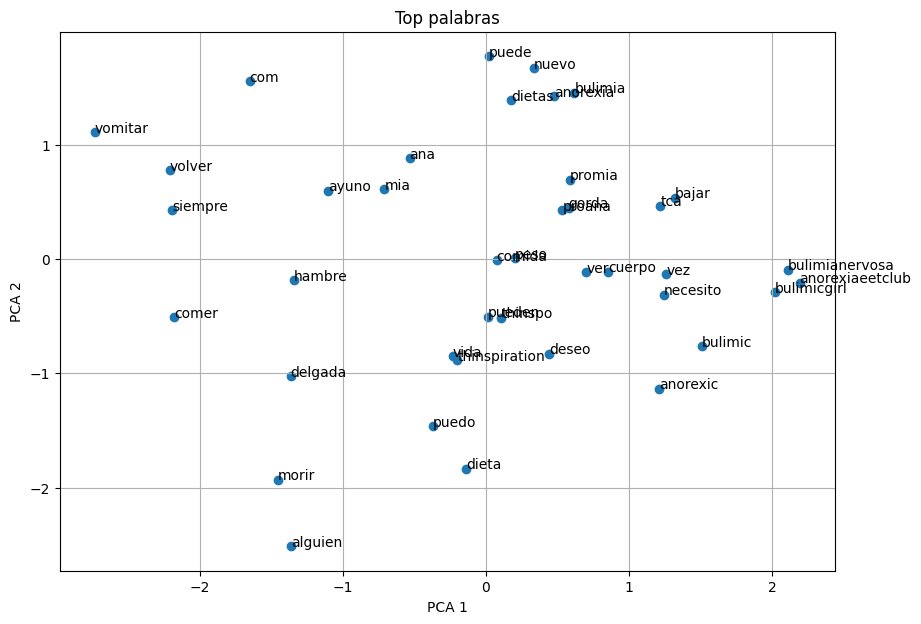

In [13]:
# se obtiene la lista de las 40 palabras más frecuentes en el vocabulario del modelo Word2Vec y se visualizan
top_words = model.wv.index_to_key[:40]
visualizar_palabras(top_words, "Top palabras")


# 11. Predicción de palabra 

In [14]:
# se define una lista de contextos para poder consultar qué palabras el modelo Word2Vec predice como más probables en esos contextos
contextos = [
    ["bajar", "peso"],
    ["comer", "culpa"],
    ["anorexia", "bulimia"],
    ["hambre", "agua"],
]

# se consulta el modelo Word2Vec para cada contexto en la lista de contextos y se imprimen las palabras más probables que el modelo predice para esos contextos
for contexto in contextos:
    contexto_presente = [p for p in contexto if p in model.wv] # se filtran las palabras del contexto para incluir solo aquellas que están presentes en el vocabulario del modelo
    print("\nContexto:", contexto_presente)
    
    #si ninguna palabra del contexto está presente en el vocabulario, se imprime un mensaje indicando que no se pueden hacer predicciones para ese contexto y se continúa con el siguiente contexto
    if len(contexto_presente) == 0:
        print("Ninguna palabra del contexto está en el vocabulario.")
        continue
    # se intenta predecir las palabras más probables para el contexto presente utilizando el modelo Word2Vec y se imprimen los resultados
    # si ocurre un error durante la predicción (por ejemplo, si el contexto no es válido para el modelo), se captura la excepción y se imprime un mensaje indicando que no se pudo predecir con ese modelo
    try:
        pred = model.predict_output_word(contexto_presente, topn=5) # se predicen las palabras más probables para el contexto presente utilizando el modelo Word2Vec
        print(pred)
    except Exception as e:
        print("No se pudo predecir con este modelo:", e)



Contexto: ['bajar', 'peso']
[('peso', np.float32(0.27122736)), ('bajar', np.float32(0.24101971)), ('amor', np.float32(0.027211923)), ('cario', np.float32(0.025187511)), ('beneficio', np.float32(0.025166968))]

Contexto: ['comer', 'culpa']
[('comer', np.float32(0.110768)), ('afecte', np.float32(0.03530299)), ('cenar', np.float32(0.033641238)), ('andrea', np.float32(0.033295143)), ('culpa', np.float32(0.0296076))]

Contexto: ['anorexia', 'bulimia']
[('bulimia', np.float32(0.020452574)), ('elche', np.float32(0.014256618)), ('hablamos', np.float32(0.0139627475)), ('pginas', np.float32(0.013543296)), ('face', np.float32(0.009948097))]

Contexto: ['hambre', 'agua']
[('hambre', np.float32(0.054959197)), ('calor', np.float32(0.02139959)), ('nutrirse', np.float32(0.019554755)), ('sed', np.float32(0.01867006)), ('lowcardiet', np.float32(0.018133854))]


# 12. Detección simple de posibles señales de anorexia

En esta sección se implementa una detección binaria sencilla para identificar si un tweet contiene posibles señales relacionadas con anorexia o trastornos de la conducta alimentaria.

In [15]:
# Dettección automática de posibles señales de anorexia/TCA en los tweets 
# de anorexia/TCA en los tweets

import re

# Lista de palabras relacionadas con anorexia/TCA
palabras_riesgo = [
    "anorexia", "anorexica", "proana",
    "no comer", "sin comer", "ayunar",
    "calorias", "bajar de peso", "perder peso",
    "thinspo", "odio mi cuerpo",
    "me siento gorda", "miedo a engordar",
    "vomitar", "atracon", "laxantes"
]

# Función para limpiar texto
def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"@\w+", "", texto)
    texto = re.sub(r"#", "", texto)
    texto = re.sub(r"[^a-záéíóúñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# Función de detección
def detectar_anorexia_tweet(tweet):

    texto = normalizar_texto(tweet)

    coincidencias = []

    for palabra in palabras_riesgo:
        if normalizar_texto(palabra) in texto:
            coincidencias.append(palabra)

    puntaje = len(coincidencias)

    if puntaje >= 2 or "anorexia" in texto or "proana" in texto:
        resultado = "Posible señal de anorexia/TCA"
    else:
        resultado = "No se detectan señales claras"

    return resultado, puntaje, coincidencias

# Analizar los tweets y mostrar resultados en una tabla

resultados = []

tweets_prueba = tweets[:10]

for tweet in tweets_prueba:

    resultado, puntaje, coincidencias = detectar_anorexia_tweet(tweet)

    resultados.append({
        "Tweet": tweet.strip(),
        "Clasificación": resultado,
        "Puntaje": puntaje,
        "Coincidencias": ", ".join(coincidencias)
    })

# Convertimos a DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostrar tabla
df_resultados


,Tweet,Clasificación,Puntaje,Coincidencias
0,thinspo y las inspiraciones que encontramos en...,Posible señal de anorexia/TCA,2,"anorexia, thinspo"
1,mis amigas no me ignoran no mienten me aconsej...,No se detectan señales claras,0,
2,hoy cenamos tostadas de aguacate con huevo poc...,No se detectan señales claras,0,
3,las mejores opciones de snacks para los pequeo...,No se detectan señales claras,0,
4,da de ayuno y hoy si que los mareos han hecho ...,No se detectan señales claras,0,
5,abastero corte de vacuno chileno al horno en c...,No se detectan señales claras,0,
6,er da desayuno una manzana almuerzo litro de a...,No se detectan señales claras,0,
7,comer hasta vomitar asu,No se detectan señales claras,1,vomitar
8,un ao que cerramos cargado de buenos deseos y ...,Posible señal de anorexia/TCA,1,anorexia
9,piensa antes de comer no comas cuando te distr...,No se detectan señales claras,0,


# 13. Comparación final de metodologías para detección de señales de anorexia/TCA



In [16]:
# 1. IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score


# Librerías necesarias para procesamiento de texto, entrenamiento y evaluación de modelos


## 14. Funciones auxiliares

Estas funciones permiten normalizar tweets, detectar señales por palabras clave y crear etiquetas binarias para entrenar los modelos.

In [17]:
# Lista de palabras relacionadas con anorexia/TCA para detección de señales en los tweets
palabras_riesgo = [
    "anorexia", "anorexica", "anoréxica", "ana", "proana", "pro ana",
    "bulimia", "bulimica", "bulímica", "mia", "promia", "pro mia",
    "no comer", "dejar de comer", "sin comer", "ayunar", "ayuno",
    "calorias", "calorías", "contar calorias", "contar calorías",
    "bajar de peso", "perder peso", "peso ideal", "estar flaca", "estar flaco",
    "quiero ser flaca", "quiero ser flaco", "thinspo", "thinspiration",
    "odio mi cuerpo", "me siento gorda", "me siento gordo",
    "miedo a engordar", "restriccion", "restricción",
    "atracon", "atracón", "vomitar", "vomito", "vómito", "purgar",
    "laxantes", "culpa por comer", "comi demasiado", "comí demasiado"
]

# Funciones auxiliares para limpieza y clasificación de texto
def normalizar_texto(texto):
    """Limpia y normaliza un texto para facilitar su análisis."""
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"#", " ", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

#función para detectar señales de anorexia/TCA en un tweet utilizando palabras clave, regresa una clasificación textual, un puntaje basado en la cantidad de coincidencias encontradas y una lista de las coincidencias específicas
def detectar_anorexia_tweet(tweet):
    texto = normalizar_texto(tweet)
    coincidencias = []

    for palabra in palabras_riesgo:
        palabra_normalizada = normalizar_texto(palabra)
        if palabra_normalizada in texto:
            coincidencias.append(palabra)

    puntaje = len(coincidencias)
    palabras_directas = ["anorexia", "anorexica", "anoréxica", "proana", "pro ana", "bulimia", "bulimica", "bulímica"]
    contiene_directa = any(normalizar_texto(p) in texto for p in palabras_directas)

    if puntaje >= 2 or contiene_directa:
        resultado = "Posible señal de anorexia/TCA"
    else:
        resultado = "No se detectan señales claras"

    return resultado, puntaje, coincidencias

# Función para tokenizar el texto: dividir en palabras, eliminar stopwords y tokens muy cortos
def tokenizar_texto(texto):
    """Tokeniza un tweet después de normalizarlo."""
    return normalizar_texto(texto).split()

# Funciones auxiliares para limpieza y clasificación de texto


## 15. Preparación automática del dataset

Esta celda es robusta: intenta usar las variables creadas anteriormente en el notebook (`df_resultados`, `df_csv`, `tweets`) o, si no existen, carga los datos desde `tweets.csv` o `tweets_limpios.txt`.

In [18]:
#Se prepara el dataset para entrenamiento de modelos, se generan etiquetas binarias basadas en la detección de señales de anorexia/TCA utilizando la función detectar_anorexia_tweet, se verifica que existan ambas clases (0 y 1) para poder entrenar modelos de clasificación posteriormente
df_modelos = None

# Reutilizar resultados generados previamente
if "df_resultados" in globals():
    df_modelos = df_resultados.copy()
    print("Se usó df_resultados existente.")

# Reutilizar dataset previamente cargado
elif "df_csv" in globals() and isinstance(df_csv, pd.DataFrame) and "tweet_text" in df_csv.columns:
    df_modelos = df_csv[["tweet_text"]].copy()
    print("Se usó df_csv existente.")

# Crear DataFrame a partir de la lista de tweets
elif "tweets" in globals():
    df_modelos = pd.DataFrame({"tweet_text": [str(t).strip() for t in tweets]})
    print("Se usó la lista tweets existente.")

# Cargar dataset desde archivo CSV
else:
    try:
        temp = pd.read_csv("tweets.csv")
        if "tweet_text" not in temp.columns:
            raise ValueError("El archivo tweets.csv no contiene la columna tweet_text.")
        df_modelos = temp[["tweet_text"]].copy()
        print("Se cargó tweets.csv.")
    except Exception as e_csv:
        try:
            with open("tweets_limpios.txt", "r", encoding="utf-8") as archivo:
                tweets_temp = archivo.readlines()
            df_modelos = pd.DataFrame({"tweet_text": [str(t).strip() for t in tweets_temp]})
            print("Se cargó tweets_limpios.txt.")
        except Exception as e_txt:
            raise FileNotFoundError("No se encontró una fuente válida de tweets. Revisa que exista tweets.csv con columna tweet_text o tweets_limpios.txt.")

# Verificar la existencia de la columna principal
if "tweet_text" not in df_modelos.columns:
    # Si por alguna razón la columna tiene otro nombre, usamos la primera columna como texto
    primera_columna = df_modelos.columns[0]
    df_modelos = df_modelos.rename(columns={primera_columna: "tweet_text"})
    print(f"Se renombró la columna {primera_columna} a tweet_text.")

# Eliminación de registros vacíos
df_modelos = df_modelos.dropna(subset=["tweet_text"])
df_modelos["tweet_text"] = df_modelos["tweet_text"].astype(str).str.strip()
df_modelos = df_modelos[df_modelos["tweet_text"] != ""]

# Generación automática de etiquetas binarias
if "clasificacion" not in df_modelos.columns or "puntaje_riesgo" not in df_modelos.columns:
    clasificaciones = []
    puntajes = []
    coincidencias_lista = []

    for tweet in df_modelos["tweet_text"]:
        resultado, puntaje, coincidencias = detectar_anorexia_tweet(tweet)
        clasificaciones.append(resultado)
        puntajes.append(puntaje)
        coincidencias_lista.append(", ".join(coincidencias))

    df_modelos["clasificacion"] = clasificaciones
    df_modelos["puntaje_riesgo"] = puntajes
    df_modelos["coincidencias"] = coincidencias_lista
    print("Se generaron clasificaciones automáticamente.")

# Conversión de etiquetas textuales a variables binarias
df_modelos["label"] = df_modelos["clasificacion"].apply(
    lambda x: 1 if "Posible señal" in str(x) else 0
)

# Verificación de clases disponibles
conteo_clases = df_modelos["label"].value_counts()
print("\nDistribución de clases:")
print(conteo_clases)

if df_modelos["label"].nunique() < 2:
    raise ValueError("El dataset solo tiene una clase. Para entrenar modelos necesitas ejemplos con label 0 y label 1.")

display(df_modelos.head(10))


Se usó df_resultados existente.
Se renombró la columna Tweet a tweet_text.
Se generaron clasificaciones automáticamente.

Distribución de clases:
label
0    7
1    3
Name: count, dtype: int64


,tweet_text,Clasificación,Puntaje,Coincidencias,clasificacion,puntaje_riesgo,coincidencias,label
0,thinspo y las inspiraciones que encontramos en...,Posible señal de anorexia/TCA,2,"anorexia, thinspo",Posible señal de anorexia/TCA,4,"anorexia, bulimia, mia, thinspo",1
1,mis amigas no me ignoran no mienten me aconsej...,No se detectan señales claras,0,,No se detectan señales claras,0,,0
2,hoy cenamos tostadas de aguacate con huevo poc...,No se detectan señales claras,0,,No se detectan señales claras,0,,0
3,las mejores opciones de snacks para los pequeo...,No se detectan señales claras,0,,No se detectan señales claras,1,ana,0
4,da de ayuno y hoy si que los mareos han hecho ...,No se detectan señales claras,0,,No se detectan señales claras,1,ayuno,0
5,abastero corte de vacuno chileno al horno en c...,No se detectan señales claras,0,,No se detectan señales claras,0,,0
6,er da desayuno una manzana almuerzo litro de a...,No se detectan señales claras,0,,Posible señal de anorexia/TCA,2,"ana, ayuno",1
7,comer hasta vomitar asu,No se detectan señales claras,1,vomitar,No se detectan señales claras,1,vomitar,0
8,un ao que cerramos cargado de buenos deseos y ...,Posible señal de anorexia/TCA,1,anorexia,Posible señal de anorexia/TCA,3,"anorexia, bulimia, mia",1
9,piensa antes de comer no comas cuando te distr...,No se detectan señales claras,0,,No se detectan señales claras,1,ana,0


## 16. Separación entrenamiento/prueba

Se usa la misma partición para todos los modelos con el fin de que la comparación sea justa.

In [19]:
#Definir train y test desde split inicial
#esto sirve para preparar los conjuntos de entrenamiento y validación utilizando el dataset generado

X_train = train_df["tweet_text"].astype(str)
y_train = train_df["class"].astype(int)

X_test = val_df["tweet_text"].astype(str)
y_test = val_df["class"].astype(int)

print("Train tamaño:", len(X_train))
print("Test tamaño:", len(X_test))

print("\nDistribución Train:")
print(y_train.value_counts())

print("\nDistribución Test:")
print(y_test.value_counts())


Train tamaño: 299
Test tamaño: 75

Distribución Train:
class
1    161
0    138
Name: count, dtype: int64

Distribución Test:
class
1    40
0    35
Name: count, dtype: int64


## 17. Función de evaluación

Todos los modelos se evalúan con la misma función para obtener métricas comparables.

In [20]:
#Evaluación de modelos de clasificación utilizando métricas como accuracy, precision, recall, f1-score y AUC, se imprime un reporte de clasificación detallado y una matriz de confusión para cada modelo evaluado

def evaluar_modelo(nombre, modelo, X_train_vec, X_test_vec, y_train, y_test):
    """Entrena un modelo y regresa sus métricas principales."""
    modelo.fit(X_train_vec, y_train)
    y_pred = modelo.predict(X_test_vec)
    
    if hasattr(modelo, "predict_proba"):
        y_scores = modelo.predict_proba(X_test_vec)[:, 1]
    else:
        y_scores = modelo.decision_function(X_test_vec)

    auc = roc_auc_score(y_test, y_scores)

    if auc < 0.5:
        auc = roc_auc_score(y_test, -y_scores)


# se imprimen las clases únicas presentes en las predicciones y en los valores reales para verificar que el modelo esté prediciendo ambas clases correctamente
    print("Predicciones únicas:", set(y_pred))
    print("Valores reales:", set(y_test))

    resultados = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": auc
    }

    print("\n==============================")
    print(nombre)
    print("==============================")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("AUC:", auc)

    return resultados

resultados_modelos = []
# Función utilizada para calcular métricas de desempeño


## 18. Word2Vec + SVM y Word2Vec + Random Forest

Word2Vec representa cada palabra como un vector. Para representar un tweet completo, se calcula el promedio de los vectores de sus palabras.

In [21]:
# Entrenamiento de modelos utilizando embeddings Word2Vec

try:
    from gensim.models import Word2Vec

    X_train_tokens = X_train.apply(tokenizar_texto).tolist()
    X_test_tokens = X_test.apply(tokenizar_texto).tolist()

    w2v_model = Word2Vec(
        sentences=X_train_tokens,
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        seed=42
    )

# función para obtener el vector promedio de las palabras en un tweet utilizando el modelo Word2Vec
    def vector_promedio(tokens, modelo, vector_size=100):
        vectores = [modelo.wv[token] for token in tokens if token in modelo.wv]
        if len(vectores) == 0:
            return np.zeros(vector_size)
        return np.mean(vectores, axis=0)

# se generan los vectores promedio para los conjuntos de entrenamiento y prueba utilizando el modelo Word2Vec
    X_train_w2v = np.array([vector_promedio(tokens, w2v_model, 100) for tokens in X_train_tokens])
    X_test_w2v = np.array([vector_promedio(tokens, w2v_model, 100) for tokens in X_test_tokens])

    print("Vectores Word2Vec creados:")
    print("Train:", X_train_w2v.shape)
    print("Test:", X_test_w2v.shape)

    modelo_w2v_svm = LinearSVC(random_state=42, max_iter=10000, class_weight="balanced")
    resultados_modelos.append(
        evaluar_modelo("Word2Vec + SVM", modelo_w2v_svm, X_train_w2v, X_test_w2v, y_train, y_test)
    )

# se entrena un modelo de Random Forest utilizando los vectores promedio generados por Word2Vec y se evalúa su desempeño utilizando la función evaluar_modelo
    modelo_w2v_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
    resultados_modelos.append(
        evaluar_modelo("Word2Vec + Random Forest", modelo_w2v_rf, X_train_w2v, X_test_w2v, y_train, y_test)
    )

#se hace una comparación de los resultados obtenidos por los modelos entrenados utilizando Word2Vec y se muestra un resumen de las métricas obtenidas para cada modelo
except Exception as e:
    print("No se pudo ejecutar Word2Vec.")
    print("Razón:", e)
    print("Si falta gensim, instala con: !pip install gensim")


Vectores Word2Vec creados:
Train: (299, 100)
Test: (75, 100)
Predicciones únicas: {np.int64(0), np.int64(1)}
Valores reales: {0, 1}

Word2Vec + SVM
              precision    recall  f1-score   support

           0       0.65      0.43      0.52        35
           1       0.62      0.80      0.70        40

    accuracy                           0.63        75
   macro avg       0.63      0.61      0.61        75
weighted avg       0.63      0.63      0.61        75

Matriz de confusión:
[[15 20]
 [ 8 32]]
AUC: 0.6457142857142858
Predicciones únicas: {np.int64(0), np.int64(1)}
Valores reales: {0, 1}

Word2Vec + Random Forest
              precision    recall  f1-score   support

           0       0.71      0.34      0.46        35
           1       0.60      0.88      0.71        40

    accuracy                           0.63        75
   macro avg       0.65      0.61      0.59        75
weighted avg       0.65      0.63      0.60        75

Matriz de confusión:
[[12 23]
 [ 5 35

## 19. Bag of Words / TF-IDF + SVM y Random Forest

TF-IDF es una variante de Bag of Words que representa los tweets según la importancia de sus palabras dentro del conjunto de datos.

In [22]:
# Entrenamiento de modelos utilizando representación TF-IDF

tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=1
)

# se generan los vectores TF-IDF para los conjuntos de entrenamiento y prueba utilizando TfidfVectorizer
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Vectores TF-IDF creados:")
print("Train:", X_train_tfidf.shape)
print("Test:", X_test_tfidf.shape)

#el modelo de SVM se entrena utilizando los vectores TF-IDF generados y se evalúa su desempeño utilizando la función evaluar_modelo
modelo_tfidf_svm = LinearSVC(random_state=42, max_iter=10000, class_weight="balanced")
resultados_modelos.append(
    evaluar_modelo("TF-IDF + SVM", modelo_tfidf_svm, X_train_tfidf, X_test_tfidf, y_train, y_test)
)

modelo_tfidf_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
resultados_modelos.append(
    evaluar_modelo("TF-IDF + Random Forest", modelo_tfidf_rf, X_train_tfidf, X_test_tfidf, y_train, y_test)
)


Vectores TF-IDF creados:
Train: (299, 3000)
Test: (75, 3000)
Predicciones únicas: {np.int64(0), np.int64(1)}
Valores reales: {0, 1}

TF-IDF + SVM
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        35
           1       0.91      0.80      0.85        40

    accuracy                           0.85        75
   macro avg       0.86      0.86      0.85        75
weighted avg       0.86      0.85      0.85        75

Matriz de confusión:
[[32  3]
 [ 8 32]]
AUC: 0.9378571428571428
Predicciones únicas: {np.int64(0), np.int64(1)}
Valores reales: {0, 1}

TF-IDF + Random Forest
              precision    recall  f1-score   support

           0       0.68      0.80      0.74        35
           1       0.79      0.68      0.73        40

    accuracy                           0.73        75
   macro avg       0.74      0.74      0.73        75
weighted avg       0.74      0.73      0.73        75

Matriz de confusión:
[[28  7]
 [13 27]]
A

## 20. Bag of Words / TF-IDF + Logistic Regression

TF-IDF combinado con Logistic Regression permite representar los tweets según la importancia de sus palabras dentro del conjunto de datos y clasificar el texto de manera lineal en función de estas características.

In [23]:
# Modelo de clasificación lineal para texto usando TF-IDF, con ajuste para clases desbalanceadas
modelo_tfidf_lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

#  Se entrena y evalúa el modelo, guardando sus métricas (incluyendo AUC) para comparación
resultados_modelos.append(
    evaluar_modelo(
        "TF-IDF + Logistic Regression",
        modelo_tfidf_lr,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test
    )
)

Predicciones únicas: {np.int64(0), np.int64(1)}
Valores reales: {0, 1}

TF-IDF + Logistic Regression
              precision    recall  f1-score   support

           0       0.73      0.91      0.81        35
           1       0.90      0.70      0.79        40

    accuracy                           0.80        75
   macro avg       0.82      0.81      0.80        75
weighted avg       0.82      0.80      0.80        75

Matriz de confusión:
[[32  3]
 [12 28]]
AUC: 0.9292857142857143


# 21. MOSTRAR PREDICCIONES DE PUBLICACIONES

In [24]:
# Usar el mejor modelo
modelo = modelo_tfidf_lr
vectorizer = tfidf_vectorizer

# Tomar algunos tweets
tweets_prueba = X_test.iloc[:10]

# Vectorizar
X_prueba_vec = vectorizer.transform(tweets_prueba)

# Predecir
predicciones = modelo.predict(X_prueba_vec)

resultados_finales = []

for tweet, pred in zip(tweets_prueba, predicciones):
    resultados_finales.append({
        "Publicación": tweet,
        "Clasificación": "Posible anorexia/TCA" if pred == 1 else "No se detecta"
    })

df_resultados_modelo = pd.DataFrame(resultados_finales)
display(df_resultados_modelo)

,Publicación,Clasificación
0,una tarta así estrenamos nuestro recetario dig...,No se detecta
1,mi día de ayer sin azúcares añadidos sinazucar,Posible anorexia/TCA
2,no entendía porque me sentía tan mal hasta que...,Posible anorexia/TCA
3,pides poca comida y dejas mas de la mitad,No se detecta
4,mi suegra intentando convencerme de que tomar ...,No se detecta
5,y luego se preguntan porque estamos enfermas y...,Posible anorexia/TCA
6,nunca he sido fan de si lo he hecho pero me da...,Posible anorexia/TCA
7,cuando improvisas y queda rico comerconciente ...,No se detecta
8,en un ayuno no hay que estar sola,Posible anorexia/TCA
9,no lo soy pero respeto a ana y a mia para algu...,Posible anorexia/TCA


## 22. Tabla comparativa final

La tabla final ordena los modelos por **F1-score**, ya que esta métrica balancea precision y recall.

In [25]:
#Función para comparar los resultados obtenidos por los modelos entrenados utilizando Word2Vec y TF-IDF

if len(resultados_modelos) == 0:
    raise ValueError("No se entrenó ningún modelo. Revisa las celdas anteriores.")
# se crea un DataFrame para comparar los resultados de los modelos entrenados, se ordena por F1-score y AUC para identificar cuál modelo tuvo el mejor desempeño en la detección de señales de anorexia/TCA en los tweets
df_comparacion = pd.DataFrame(resultados_modelos)
df_comparacion = df_comparacion.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

df_comparacion = df_comparacion.sort_values(by=["F1-score", "AUC"], ascending=False).reset_index(drop=True)

display(df_comparacion)

mejor_modelo = df_comparacion.iloc[0]

print("Mejor modelo según F1-score:")
print("Modelo:", mejor_modelo["Modelo"])
print("F1-score:", mejor_modelo["F1-score"])
print("Accuracy:", mejor_modelo["Accuracy"])
print("Precision:", mejor_modelo["Precision"])
print("Recall:", mejor_modelo["Recall"])
print("AUC:", mejor_modelo["AUC"])

# Resumen
print("\nResumen:")
print(f"Total de tweets evaluados: {len(X_test)}")
print(f"Tweets posible TCA (ground truth): {sum(y_test)}")
print(f"Tweets sin TCA: {len(y_test) - sum(y_test)}")

# Exportación de resultados comparativos
df_comparacion.to_csv("comparacion_modelos_anorexia_tca.csv", index=False)
print("\nArchivo generado: comparacion_modelos_anorexia_tca.csv")


,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,TF-IDF + SVM,0.853333,0.914286,0.800,0.853333,0.937857
1,TF-IDF + Logistic Regression,0.800000,0.903226,0.700,0.788732,0.929286
2,TF-IDF + Random Forest,0.733333,0.794118,0.675,0.729730,0.833929
3,Word2Vec + Random Forest,0.626667,0.603448,0.875,0.714286,0.693214
4,Word2Vec + SVM,0.626667,0.615385,0.800,0.695652,0.645714


Mejor modelo según F1-score:
Modelo: TF-IDF + SVM
F1-score: 0.8533333333333334
Accuracy: 0.8533333333333334
Precision: 0.9142857142857143
Recall: 0.8
AUC: 0.9378571428571428

Resumen:
Total de tweets evaluados: 75
Tweets posible TCA (ground truth): 40
Tweets sin TCA: 35

Archivo generado: comparacion_modelos_anorexia_tca.csv


# Fase 3 (Evidencia 2): Método con LLM real usando Ollama

En esta fase se implementa un método adicional de detección de posibles señales de anorexia/TCA utilizando un **Large Language Model (LLM)** mediante **Zero-Shot Prompting**.

Para evitar depender de APIs comerciales, se propone el uso de **Ollama**, una herramienta que permite ejecutar modelos de lenguaje de forma local, como `llama3`, `mistral` o `gemma`.

El objetivo es comparar el método basado en LLM contra las metodologías anteriores del notebook, como Word2Vec + SVM, Word2Vec + Random Forest, TF-IDF + SVM y TF-IDF + Random Forest.

## 1. Requisitos para usar Ollama

Para ejecutar esta sección con un LLM real se necesita tener Ollama instalado y corriendo en la computadora.

Pasos recomendados:

1. Instalar Ollama desde su sitio oficial.
2. Abrir una terminal.
3. Descargar un modelo, por ejemplo:

```bash
ollama pull phi3
ollama pull gemma
ollama pull mistral
```

4. Verificar que Ollama esté activo. Normalmente corre en:

```text
http://localhost:11434
```

Si Ollama no está disponible, el notebook usará una versión simulada para que el flujo pueda ejecutarse sin romperse.

## 2. Preparación de variables para Fase 3

Esta celda corrige el problema de variables no definidas. En lugar de asumir que existe una variable llamada `X`, se busca automáticamente el DataFrame disponible en el notebook y se extraen los tweets y etiquetas.

In [26]:
# Preparación robusta del dataset para la Fase 3

import pandas as pd
import numpy as np
import re
import json
import requests

# Se intenta reutilizar el dataset creado en las fases anteriores.
if "df_modelos" in globals() and isinstance(df_modelos, pd.DataFrame):
    df_fase3 = df_modelos.copy()
elif "df_clasificacion_final" in globals() and isinstance(df_clasificacion_final, pd.DataFrame):
    df_fase3 = df_clasificacion_final.copy()
elif "df_resultados" in globals() and isinstance(df_resultados, pd.DataFrame):
    df_fase3 = df_resultados.copy()
elif "tweets" in globals():
    df_fase3 = pd.DataFrame({"tweet_text": [str(t).strip() for t in tweets]})
else:
    try:
        df_fase3 = pd.read_csv("tweets.csv")
    except Exception:
        with open("tweets_limpios.txt", "r", encoding="utf-8") as archivo:
            tweets_tmp = archivo.readlines()
        df_fase3 = pd.DataFrame({"tweet_text": [str(t).strip() for t in tweets_tmp]})

# Asegurar que exista la columna tweet_text.
if "tweet_text" not in df_fase3.columns:
    primera_columna = df_fase3.columns[0]
    df_fase3 = df_fase3.rename(columns={primera_columna: "tweet_text"})

df_fase3 = df_fase3.dropna(subset=["tweet_text"])
df_fase3["tweet_text"] = df_fase3["tweet_text"].astype(str).str.strip()
df_fase3 = df_fase3[df_fase3["tweet_text"] != ""].reset_index(drop=True)

# Si no existe label, se genera a partir de reglas previas.
if "label" not in df_fase3.columns:
    if "clasificacion" in df_fase3.columns:
        df_fase3["label"] = df_fase3["clasificacion"].apply(
            lambda x: 1 if "Posible señal" in str(x) else 0
        )
    elif "resultado" in df_fase3.columns:
        df_fase3["label"] = df_fase3["resultado"].apply(
            lambda x: 1 if "Posible señal" in str(x) else 0
        )
    elif "class" in df_fase3.columns:
        df_fase3["label"] = df_fase3["class"].apply(
            lambda x: 1 if str(x).lower().strip() in ["anorexia", "1", "positive", "positivo"] else 0
        )
    else:
        # Último recurso: usar la función de reglas si existe.
        if "detectar_anorexia_tweet" not in globals():
            def normalizar_texto(texto):
                texto = str(texto).lower()
                texto = re.sub(r"http\S+|www\S+", " ", texto)
                texto = re.sub(r"@\w+", " ", texto)
                texto = re.sub(r"#", " ", texto)
                texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
                texto = re.sub(r"\s+", " ", texto).strip()
                return texto

            def detectar_anorexia_tweet(tweet):
                texto = normalizar_texto(tweet)
                patrones = ["anorexia", "bulimia", "proana", "no comer", "ayunar", "calorias", "miedo a engordar", "vomitar", "laxantes"]
                coincidencias = [p for p in patrones if normalizar_texto(p) in texto]
                if len(coincidencias) >= 1:
                    return "Posible señal de anorexia/TCA", len(coincidencias), coincidencias
                return "No se detectan señales claras", 0, []

        df_fase3["label"] = df_fase3["tweet_text"].apply(
            lambda t: 1 if "Posible señal" in detectar_anorexia_tweet(t)[0] else 0
        )

# Variables finales para esta fase.
X_fase3 = df_fase3["tweet_text"].astype(str)
y_fase3 = df_fase3["label"].astype(int)

print("Dataset listo para Fase 3")
print("Total de tweets:", len(X_fase3))
print("Distribución de clases:")
print(y_fase3.value_counts())

display(df_fase3.head(10))


Dataset listo para Fase 3
Total de tweets: 10
Distribución de clases:
label
0    7
1    3
Name: count, dtype: int64


,tweet_text,Clasificación,Puntaje,Coincidencias,clasificacion,puntaje_riesgo,coincidencias,label
0,thinspo y las inspiraciones que encontramos en...,Posible señal de anorexia/TCA,2,"anorexia, thinspo",Posible señal de anorexia/TCA,4,"anorexia, bulimia, mia, thinspo",1
1,mis amigas no me ignoran no mienten me aconsej...,No se detectan señales claras,0,,No se detectan señales claras,0,,0
2,hoy cenamos tostadas de aguacate con huevo poc...,No se detectan señales claras,0,,No se detectan señales claras,0,,0
3,las mejores opciones de snacks para los pequeo...,No se detectan señales claras,0,,No se detectan señales claras,1,ana,0
4,da de ayuno y hoy si que los mareos han hecho ...,No se detectan señales claras,0,,No se detectan señales claras,1,ayuno,0
5,abastero corte de vacuno chileno al horno en c...,No se detectan señales claras,0,,No se detectan señales claras,0,,0
6,er da desayuno una manzana almuerzo litro de a...,No se detectan señales claras,0,,Posible señal de anorexia/TCA,2,"ana, ayuno",1
7,comer hasta vomitar asu,No se detectan señales claras,1,vomitar,No se detectan señales claras,1,vomitar,0
8,un ao que cerramos cargado de buenos deseos y ...,Posible señal de anorexia/TCA,1,anorexia,Posible señal de anorexia/TCA,3,"anorexia, bulimia, mia",1
9,piensa antes de comer no comas cuando te distr...,No se detectan señales claras,0,,No se detectan señales claras,1,ana,0


## 3. Prompt Zero-Shot para el LLM

El LLM se usa como un clasificador guiado por instrucciones. Para cada tweet se construye un prompt que le pide responder únicamente con una de dos clases:

- `POSIBLE ANOREXIA/TCA`
- `NO SE DETECTAN SEÑALES`

Esto permite usar el modelo sin reentrenarlo.

In [27]:
# Construcción del prompt Zero-Shot

def construir_prompt_llm(tweet):
    """Genera el prompt de clasificación para el LLM."""
    return f"""
Eres un asistente que clasifica textos de redes sociales.

Tarea:
Clasifica el siguiente tweet en una sola categoría.

Categorías permitidas:
- POSIBLE ANOREXIA/TCA
- NO SE DETECTAN SEÑALES

Criterios:
- Usa POSIBLE ANOREXIA/TCA si el texto menciona señales como anorexia, bulimia, restricción alimentaria, miedo a engordar, vómito, culpa por comer, obsesión por calorías o deseo extremo de bajar de peso.
- Usa NO SE DETECTAN SEÑALES si no hay indicios claros relacionados con trastornos alimenticios.
- No hagas diagnóstico clínico.
- Responde únicamente con una de las dos categorías permitidas.

Tweet: \"{tweet}\"

Respuesta:
""".strip()

print(construir_prompt_llm("Odio mi cuerpo y quiero dejar de comer"))


Eres un asistente que clasifica textos de redes sociales.

Tarea:
Clasifica el siguiente tweet en una sola categoría.

Categorías permitidas:
- POSIBLE ANOREXIA/TCA
- NO SE DETECTAN SEÑALES

Criterios:
- Usa POSIBLE ANOREXIA/TCA si el texto menciona señales como anorexia, bulimia, restricción alimentaria, miedo a engordar, vómito, culpa por comer, obsesión por calorías o deseo extremo de bajar de peso.
- Usa NO SE DETECTAN SEÑALES si no hay indicios claros relacionados con trastornos alimenticios.
- No hagas diagnóstico clínico.
- Responde únicamente con una de las dos categorías permitidas.

Tweet: "Odio mi cuerpo y quiero dejar de comer"

Respuesta:


## 4. Clasificación con Ollama

Esta función intenta conectarse con Ollama en `localhost:11434`. Si Ollama está activo y el modelo está descargado, se obtiene una respuesta real del LLM.

Si no se puede conectar, la función regresa `None` y más adelante se usa un respaldo local para no detener la ejecución del notebook.

In [28]:
# Clasificador real usando Ollama

OLLAMA_MODEL = "mistral"  # También puede usarse: "mistral", "gemma", etc.
OLLAMA_URL = "http://localhost:11434/api/generate"

def clasificar_con_ollama(tweet, model=OLLAMA_MODEL, timeout=60):
    """
    Envía el prompt a un LLM local mediante Ollama.
    Regresa 1 para posible señal y 0 para no señal.
    Si Ollama no está disponible, regresa None.
    """
    prompt = construir_prompt_llm(tweet)

    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0
        }
    }

    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
        response.raise_for_status()
        respuesta = response.json().get("response", "").strip().upper()

        if "POSIBLE ANOREXIA" in respuesta or "TCA" in respuesta:
            return 1, "POSIBLE ANOREXIA/TCA", respuesta
        if "NO SE DETECTAN" in respuesta or "NO" in respuesta:
            return 0, "NO SE DETECTAN SEÑALES", respuesta

        # En caso de respuesta ambigua, se considera no señal para evitar sobreclasificar.
        return 0, "NO SE DETECTAN SEÑALES", respuesta

    except Exception as e:
        return None, "OLLAMA NO DISPONIBLE", str(e)

# Prueba de conexión con Ollama
pred_test, etiqueta_test, respuesta_test = clasificar_con_ollama("Tengo miedo a engordar y quiero dejar de comer")

print("Predicción:", pred_test)
print("Etiqueta:", etiqueta_test)
print("Respuesta cruda / estado:", respuesta_test)


Predicción: 1
Etiqueta: POSIBLE ANOREXIA/TCA
Respuesta cruda / estado: POSIBLE ANOREXIA/TCA


## 5. Respaldo local si Ollama no está disponible

Para que el notebook sea reproducible en cualquier equipo, se define un respaldo local basado en los mismos criterios del prompt. Este respaldo solo se usa si Ollama no está activo o si el modelo no está descargado.

In [29]:
# Respaldo local basado en reglas del prompt

def clasificar_respaldo_local(tweet):
    """Clasificación local si Ollama no está disponible."""
    texto = normalizar_texto(tweet) if "normalizar_texto" in globals() else str(tweet).lower()

    patrones = [
        "anorexia", "anorexica", "anoréxica", "bulimia", "bulimica", "bulímica",
        "proana", "pro ana", "promia", "pro mia", "no comer", "dejar de comer",
        "sin comer", "ayunar", "ayuno", "calorias", "calorías", "contar calorias",
        "contar calorías", "bajar de peso", "perder peso", "miedo a engordar",
        "odio mi cuerpo", "me siento gorda", "me siento gordo", "vomitar",
        "vomito", "vómito", "purgar", "laxantes", "culpa por comer", "thinspo"
    ]

    coincidencias = []
    for patron in patrones:
        patron_limpio = normalizar_texto(patron) if "normalizar_texto" in globals() else patron.lower()
        if patron_limpio in texto:
            coincidencias.append(patron)

    if len(coincidencias) >= 1:
        return 1, "POSIBLE ANOREXIA/TCA", ", ".join(coincidencias)

    return 0, "NO SE DETECTAN SEÑALES", ""


## 6. Aplicación del LLM al dataset

Para evitar que la ejecución tarde demasiado, se evalúa una muestra de tweets. El tamaño puede modificarse con la variable `N_LLM`.

Si Ollama está disponible, se usa el LLM real. Si no, se usa el respaldo local.

In [30]:
# Aplicación del método LLM/Ollama al dataset

N_LLM = min(50, len(X_fase3))  # Cambiar a len(X_fase3) para evaluar todos los tweets

X_llm = X_fase3.iloc[:N_LLM].reset_index(drop=True)
y_llm = y_fase3.iloc[:N_LLM].reset_index(drop=True)

predicciones_llm = []
etiquetas_llm = []
respuestas_llm = []
fuente_llm = []

for tweet in X_llm:
    pred, etiqueta, respuesta = clasificar_con_ollama(tweet)

    if pred is None:
        pred, etiqueta, respuesta = clasificar_respaldo_local(tweet)
        fuente = "Respaldo local"
    else:
        fuente = "Ollama LLM real"

    predicciones_llm.append(pred)
    etiquetas_llm.append(etiqueta)
    respuestas_llm.append(respuesta)
    fuente_llm.append(fuente)

df_llm_resultados = pd.DataFrame({
    "tweet_text": X_llm.values,
    "label_real": y_llm.values,
    "prediccion_llm": predicciones_llm,
    "resultado_llm": etiquetas_llm,
    "respuesta_modelo": respuestas_llm,
    "fuente": fuente_llm
})

display(df_llm_resultados.head(20))
print("Fuente usada:")
print(df_llm_resultados["fuente"].value_counts())


,tweet_text,label_real,prediccion_llm,resultado_llm,respuesta_modelo,fuente
0,thinspo y las inspiraciones que encontramos en...,1,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama LLM real
1,mis amigas no me ignoran no mienten me aconsej...,0,0,NO SE DETECTAN SEÑALES,NO SE DETECTAN SEÑALES,Ollama LLM real
2,hoy cenamos tostadas de aguacate con huevo poc...,0,0,NO SE DETECTAN SEÑALES,NO SE DETECTAN SEÑALES,Ollama LLM real
3,las mejores opciones de snacks para los pequeo...,0,0,NO SE DETECTAN SEÑALES,NO SE DETECTAN SEÑALES,Ollama LLM real
4,da de ayuno y hoy si que los mareos han hecho ...,0,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama LLM real
5,abastero corte de vacuno chileno al horno en c...,0,0,NO SE DETECTAN SEÑALES,NO SE DETECTAN SEÑALES,Ollama LLM real
6,er da desayuno una manzana almuerzo litro de a...,1,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama LLM real
7,comer hasta vomitar asu,0,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama LLM real
8,un ao que cerramos cargado de buenos deseos y ...,1,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama LLM real
9,piensa antes de comer no comas cuando te distr...,0,0,NO SE DETECTAN SEÑALES,NO SE DETECTAN SEÑALES,Ollama LLM real


Fuente usada:
fuente
Ollama LLM real    10
Name: count, dtype: int64


## 7. Evaluación del método LLM

Se calculan las mismas métricas usadas en la Fase 2 para poder comparar ambos enfoques: accuracy, precision, recall y F1-score.

In [31]:
# Evaluación del método LLM/Ollama

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy_llm = accuracy_score(y_llm, predicciones_llm)
precision_llm = precision_score(y_llm, predicciones_llm, zero_division=0)
recall_llm = recall_score(y_llm, predicciones_llm, zero_division=0)
f1_llm = f1_score(y_llm, predicciones_llm, zero_division=0)

resultado_llm = {
    "Modelo": "Ollama LLM Zero-Shot",
    "Accuracy": accuracy_llm,
    "Precision": precision_llm,
    "Recall": recall_llm,
    "F1-score": f1_llm
}

print("Resultados del método LLM:")
print(resultado_llm)

print("\nReporte de clasificación:")
print(classification_report(y_llm, predicciones_llm, zero_division=0))

print("Matriz de confusión:")
print(confusion_matrix(y_llm, predicciones_llm))


Resultados del método LLM:
{'Modelo': 'Ollama LLM Zero-Shot', 'Accuracy': 0.8, 'Precision': 0.6, 'Recall': 1.0, 'F1-score': 0.75}

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.60      1.00      0.75         3

    accuracy                           0.80        10
   macro avg       0.80      0.86      0.79        10
weighted avg       0.88      0.80      0.81        10

Matriz de confusión:
[[5 2]
 [0 3]]


## 8. Comparación contra la herramienta de Fase 2

En esta sección se integra el resultado del LLM con la tabla comparativa generada previamente. Si la tabla `df_comparacion` no existe, se crea una tabla con el resultado del LLM para evitar errores.

In [32]:
# Comparación Fase 2 vs Fase 3

if "df_comparacion" in globals() and isinstance(df_comparacion, pd.DataFrame):
    df_comparacion_fase3 = df_comparacion.copy()
    df_comparacion_fase3 = df_comparacion_fase3[
        df_comparacion_fase3["Modelo"] != "Ollama LLM Zero-Shot"
    ]
    df_comparacion_fase3 = pd.concat(
        [df_comparacion_fase3, pd.DataFrame([resultado_llm])],
        ignore_index=True
    )
else:
    df_comparacion_fase3 = pd.DataFrame([resultado_llm])

df_comparacion_fase3 = df_comparacion_fase3.sort_values(
    by="F1-score", ascending=False
).reset_index(drop=True)

display(df_comparacion_fase3)

mejor_modelo_fase3 = df_comparacion_fase3.iloc[0]

print("Mejor método global:", mejor_modelo_fase3["Modelo"])
print("F1-score:", mejor_modelo_fase3["F1-score"])
print("Accuracy:", mejor_modelo_fase3["Accuracy"])
print("Precision:", mejor_modelo_fase3["Precision"])
print("Recall:", mejor_modelo_fase3["Recall"])


,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,TF-IDF + SVM,0.853333,0.914286,0.800,0.853333,0.937857
1,TF-IDF + Logistic Regression,0.800000,0.903226,0.700,0.788732,0.929286
2,Ollama LLM Zero-Shot,0.800000,0.600000,1.000,0.750000,NaN
3,TF-IDF + Random Forest,0.733333,0.794118,0.675,0.729730,0.833929
4,Word2Vec + Random Forest,0.626667,0.603448,0.875,0.714286,0.693214
5,Word2Vec + SVM,0.626667,0.615385,0.800,0.695652,0.645714


Mejor método global: TF-IDF + SVM
F1-score: 0.8533333333333334
Accuracy: 0.8533333333333334
Precision: 0.9142857142857143
Recall: 0.8


## 9. Evidencia de mérito relativo

El mérito relativo del método LLM se demuestra comparando sus métricas contra las obtenidas por los modelos clásicos de la Fase 2.

Los modelos clásicos requieren entrenamiento y dependen de representaciones como Word2Vec o TF-IDF. En cambio, el LLM puede clasificar mediante instrucciones en lenguaje natural, sin reentrenamiento.

Si el LLM obtiene mejores métricas, se puede decir que mejora la herramienta anterior en desempeño. Si obtiene métricas similares o menores, sigue aportando valor por su flexibilidad, facilidad de ajuste mediante prompts y capacidad de trabajar con texto no visto.

# 10. Método Transformer: Sentence-BERT + SVM

En esta sección se agrega un método basado en **Transformers**, siguiendo la metodología propuesta para modelos avanzados de lenguaje:

1. Cargar un modelo preentrenado.
2. Tokenizar los textos internamente con el modelo.
3. Obtener embeddings semánticos de cada tweet.
4. Usar esos embeddings como entrada para un clasificador tradicional.

Para esta implementación se utiliza **Sentence-BERT**, una variante basada en BERT diseñada para obtener representaciones vectoriales de oraciones o textos completos. Después, los embeddings generados se clasifican mediante **SVM**.

Además de accuracy, precision, recall y F1-score, se calcula **AUC**, métrica útil para evaluar qué tan bien el modelo separa las dos clases.

In [33]:

from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC

def calcular_auc_seguro(y_real, scores):
    """Calcula AUC-ROC cuando existen ambas clases en la muestra."""
    try:
        if len(set(y_real)) < 2:
            return np.nan
        return roc_auc_score(y_real, scores)
    except Exception:
        return np.nan

def evaluar_modelo_auc(nombre, modelo, X_train_vec, X_test_vec, y_train, y_test):
    """Entrena un modelo y calcula métricas de clasificación con AUC-ROC."""
    modelo.fit(X_train_vec, y_train)
    y_pred = modelo.predict(X_test_vec)

    if hasattr(modelo, "decision_function"):
        scores = modelo.decision_function(X_test_vec)
    elif hasattr(modelo, "predict_proba"):
        scores = modelo.predict_proba(X_test_vec)[:, 1]
    else:
        scores = y_pred

    auc = calcular_auc_seguro(y_test, scores)

    resultado = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": auc
    }

    print("\n==============================")
    print(nombre)
    print("==============================")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("AUC-ROC:", auc)

    return resultado


In [34]:
%pip install sentence-transformers


Note: you may need to restart the kernel to use updated packages.


## 11. Entrenamiento de Sentence-BERT + SVM

Se usa el modelo preentrenado `all-MiniLM-L6-v2` para generar embeddings de los tweets. Luego, estos vectores se utilizan como entrada para un SVM con kernel lineal.

In [35]:
# Sentence-BERT + SVM

try:
    from sentence_transformers import SentenceTransformer

    # Selección de datos de entrenamiento y prueba.
    if "X_train" in globals() and "X_test" in globals() and "y_train" in globals() and "y_test" in globals():
        X_train_bert_text = X_train.astype(str)
        X_test_bert_text = X_test.astype(str)
        y_train_bert = y_train
        y_test_bert = y_test
    else:
        from sklearn.model_selection import train_test_split
        X_train_bert_text, X_test_bert_text, y_train_bert, y_test_bert = train_test_split(
            X_fase3.astype(str),
            y_fase3.astype(int),
            test_size=0.2,
            random_state=42,
            stratify=y_fase3 if y_fase3.value_counts().min() >= 2 else None
        )

    # Carga del Transformer preentrenado.
    sentence_bert_model = SentenceTransformer("all-MiniLM-L6-v2")

    # Obtención de embeddings semánticos.
    X_train_bert = sentence_bert_model.encode(
        X_train_bert_text.tolist(),
        show_progress_bar=True
    )

    X_test_bert = sentence_bert_model.encode(
        X_test_bert_text.tolist(),
        show_progress_bar=True
    )

    print("Embeddings Sentence-BERT generados")
    print("Train:", X_train_bert.shape)
    print("Test:", X_test_bert.shape)

    # SVM con probabilidad para calcular AUC-ROC.
    modelo_bert_svm = SVC(
        kernel="linear",
        probability=True,
        random_state=42
    )

    resultado_bert_svm = evaluar_modelo_auc(
        "Sentence-BERT + SVM",
        modelo_bert_svm,
        X_train_bert,
        X_test_bert,
        y_train_bert,
        y_test_bert
    )

except Exception as e:
    print("No se pudo ejecutar Sentence-BERT + SVM.")
    print("Razón:", e)
    print("Si falta la librería, ejecuta: !pip install sentence-transformers")
    resultado_bert_svm = None


/opt/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 3/3 [00:00<00:00,  6.12it/s]

Embeddings Sentence-BERT generados
Train: (299, 384)
Test: (75, 384)

Sentence-BERT + SVM
              precision    recall  f1-score   support

           0       0.87      0.77      0.82        35
           1       0.82      0.90      0.86        40

    accuracy                           0.84        75
   macro avg       0.84      0.84      0.84        75
weighted avg       0.84      0.84      0.84        75

Matriz de confusión:
[[27  8]
 [ 4 36]]
AUC-ROC: 0.9028571428571428


## 12.

In [36]:
if 'df_comparacion_auc' in globals():
    if 'AUC' not in df_comparacion_auc.columns:
        df_comparacion_auc['AUC'] = np.nan

    if 'AUC-ROC' in df_comparacion_auc.columns:
        df_comparacion_auc['AUC'] = df_comparacion_auc['AUC'].fillna(df_comparacion_auc['AUC-ROC'])
        df_comparacion_auc = df_comparacion_auc.drop(columns=['AUC-ROC'])

    display(df_comparacion_auc)
    df_comparacion_auc.to_csv('comparacion_final.csv', index=False)
    print('Archivo generado: comparacion_final.csv')



## 13. Prompts Zero-Shot y Few-Shot

Zero-Shot clasifica sin ejemplos. Few-Shot añade ejemplos positivos y negativos para guiar al modelo.

In [37]:
def construir_prompt_zero_shot(tweet):
    """Prompt Zero-Shot para clasificación binaria."""
    return f"""

Eres un clasificador de tweets relacionados con trastornos alimenticios.

Tu tarea es identificar si el tweet contiene señales de:
- anorexia
- bulimia
- ayuno extremo
- miedo a engordar
- odio corporal
- dejar de comer
- vómito inducido
- thinspo
- conductas alimenticias peligrosas


IMPORTANTE:
- Solo puedes responder con UNA de las dos opciones EXACTAS
- No expliques
- No agregues palabras
- No des ejemplos

Opciones válidas:

POSIBLE ANOREXIA/TCA
NO SE DETECTAN SEÑALES

Tweet: "{tweet}"

Respuesta (elige EXACTAMENTE una opción):
""".strip()

def construir_prompt_few_shot(tweet):
    """Prompt Few-Shot con ejemplos positivos y negativos."""
    return f"""

Clasifica tweets relacionados con anorexia y trastornos alimenticios.

Ejemplos:

Tweet: "Hoy no quiero comer nada"
Respuesta: POSIBLE ANOREXIA/TCA

Tweet: "Odio mi cuerpo y necesito adelgazar"
Respuesta: POSIBLE ANOREXIA/TCA

Tweet: "Voy a vomitar después de comer"
Respuesta: POSIBLE ANOREXIA/TCA

Tweet: "Me encantan los tacos"
Respuesta: NO SE DETECTAN SEÑALES

Tweet: "Hoy fui al gimnasio"
Respuesta: NO SE DETECTAN SEÑALES

Ahora clasifica este tweet.

IMPORTANTE:
- Solo puedes responder con UNA de las dos opciones EXACTAS
- No expliques
- No agregues palabras
- No des ejemplos

Opciones válidas:

POSIBLE ANOREXIA/TCA
NO SE DETECTAN SEÑALES


Tweet: "{tweet}"
Respuesta (elige EXACTAMENTE una opción):
""".strip()

print(construir_prompt_few_shot("tengo miedo a engordar"))


Clasifica tweets relacionados con anorexia y trastornos alimenticios.

Ejemplos:

Tweet: "Hoy no quiero comer nada"
Respuesta: POSIBLE ANOREXIA/TCA

Tweet: "Odio mi cuerpo y necesito adelgazar"
Respuesta: POSIBLE ANOREXIA/TCA

Tweet: "Voy a vomitar después de comer"
Respuesta: POSIBLE ANOREXIA/TCA

Tweet: "Me encantan los tacos"
Respuesta: NO SE DETECTAN SEÑALES

Tweet: "Hoy fui al gimnasio"
Respuesta: NO SE DETECTAN SEÑALES

Ahora clasifica este tweet.

IMPORTANTE:
- Solo puedes responder con UNA de las dos opciones EXACTAS
- No expliques
- No agregues palabras
- No des ejemplos

Opciones válidas:

POSIBLE ANOREXIA/TCA
NO SE DETECTAN SEÑALES


Tweet: "tengo miedo a engordar"
Respuesta (elige EXACTAMENTE una opción):


## 14. Funciones de conexión: Ollama, Hugging Face y OpenAI

Para OpenAI y Hugging Face se usan variables de entorno:

- `OPENAI_API_KEY`
- `HF_API_TOKEN`

Si no están configuradas, el notebook usa respaldo local para mantener la ejecución completa.

In [38]:
%pip install cohere

Note: you may need to restart the kernel to use updated packages.


## 15. 

In [39]:
# Función global de limpieza para reutilizar en todo el notebook
import re

def limpiar_tweet_text(texto):
    """Limpia texto de tweets para análisis y respaldo local de LLMs."""
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"#", " ", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


## 16.

In [40]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [ ]:

from dotenv import load_dotenv
import os

load_dotenv()

import requests
import os
import re
import cohere

OLLAMA_URL = "http://localhost:11434/api/generate"
OLLAMA_MODEL = ["phi3:latest", "mistral:latest", "gemma:latest"]

#COHERE API KEY
# Crear cuenta en https://cohere.com/ para obtener tu API key gratuita y usar sus modelos de lenguaje.
COHERE_API_KEY = os.getenv("COHERE_API_KEY")
COHERE_MODEL = "command-a-03-2025"
co = cohere.Client(COHERE_API_KEY)


# GROQ API KEY
# Crear cuenta en https://groq.com/ para obtener tu API key gratuita y usar sus modelos de lenguaje.
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

GROQ_MODEL = "llama-3.1-8b-instant"

GROQ_API_URL = "https://api.groq.com/openai/v1/chat/completions"



'''
def interpretar_respuesta_llm(respuesta):

    respuesta = str(respuesta).strip().lower()

    if "posible anorexia" in respuesta:
        return 1, "POSIBLE ANOREXIA/TCA"

    if "tca" in respuesta:
        return 1, "POSIBLE ANOREXIA/TCA"

    if "no se detectan" in respuesta:
        return 0, "NO SE DETECTAN SEÑALES"

    return 0, "NO SE DETECTAN SEÑALES"
    '''

def interpretar_respuesta_llm(respuesta):

    respuesta = str(respuesta).strip().lower()

    positivos = [
        "posible",
        "tca",
        "anorexia",
        "bulimia",
        "thinspo"
    ]

    negativos = [
        "no se detectan",
        "no hay señales",
        "ninguna señal"
    ]

    for p in positivos:
        if p in respuesta:
            return 1, "POSIBLE ANOREXIA/TCA"

    for n in negativos:
        if n in respuesta:
            return 0, "NO SE DETECTAN SEÑALES"

    return 0, "NO SE DETECTAN SEÑALES"


def respaldo_local(tweet):
    """Respaldo determinista si una API no está disponible."""
    texto = str(tweet).lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"#", " ", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    patrones = [
        "anorexia", "bulimia", "proana", "promia", "no comer",
        "dejar de comer", "sin comer", "ayunar", "calorias",
        "bajar de peso", "perder peso", "miedo a engordar",
        "odio mi cuerpo", "me siento gorda", "vomitar", "laxantes",
        "culpa por comer", "thinspo"
    ]

    for patron in patrones:
        patron_limpio = str(patron).lower()
        patron_limpio = re.sub(r"[^a-záéíóúñü\s]", " ", patron_limpio)
        patron_limpio = re.sub(r"\s+", " ", patron_limpio).strip()

        if patron_limpio in texto:
            return 1, "POSIBLE ANOREXIA/TCA", patron, "Respaldo local"

    return 0, "NO SE DETECTAN SEÑALES", "", "Respaldo local"

def consultar_ollama(prompt, modelo, timeout=60):
    """Consulta un modelo local mediante Ollama."""
    payload = {
        "model": modelo,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": 0}
    }

    try:
        r = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
        r.raise_for_status()
        return r.json().get("response", "").strip(), f"Ollama ({modelo})"
    except Exception as e:
        return f"ERROR_OLLAMA_{modelo}: {e}", "Error"


    
def consultar_cohere(prompt):

    try:

        response = co.chat(
            model=COHERE_MODEL,
            message=prompt,
            temperature=0,
            max_tokens=20
        )

        respuesta = response.text.strip()

        return respuesta, "Cohere"

    except Exception as e:

        print("ERROR COHERE:", e)

        return f"ERROR_COHERE: {e}", "Error"
    


def consultar_groq(prompt, timeout=60):

    headers = {
        "Authorization": f"Bearer {GROQ_API_KEY}",
        "Content-Type": "application/json"
    }

    payload = {
        "model": GROQ_MODEL,
        "messages": [
            {
                "role": "system",
                "content": """
Clasifica tweets relacionados con anorexia y TCA.

Responde SOLO UNA opción EXACTA:

POSIBLE ANOREXIA/TCA
NO SE DETECTAN SEÑALES
"""
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        "temperature": 0,
        "max_tokens": 10
    }

    try:

        r = requests.post(
            GROQ_API_URL,
            headers=headers,
            json=payload,
            timeout=timeout
        )

        r.raise_for_status()

        data = r.json()

        respuesta = data["choices"][0]["message"]["content"].strip()

        return respuesta, "Groq"

    except Exception as e:

        print("ERROR GROQ:", e)

        return f"ERROR_GROQ: {e}", "Error"
    


def clasificar_con_enfoque_llm(tweet, enfoque, estrategia):
    """Clasifica un tweet con el enfoque LLM y estrategia seleccionados."""
    prompt = construir_prompt_zero_shot(tweet) if estrategia == "Zero-Shot" else construir_prompt_few_shot(tweet)

    if enfoque.startswith("Ollama"):
        modelo = enfoque.split(" - ")[1]
        respuesta, fuente = consultar_ollama(prompt, modelo)
    elif enfoque == "Cohere API":
        respuesta, fuente = consultar_cohere(prompt)
    elif enfoque == "Groq API":
        respuesta, fuente = consultar_groq(prompt)
    else:
        raise ValueError("Enfoque LLM no válido")


    # DEBUG
    print("RESPUESTA REAL:", respuesta)
    print("FUENTE:", fuente)
    print("-" * 80)
    

    if fuente != "Error":
        pred, etiqueta = interpretar_respuesta_llm(respuesta)
        return pred, etiqueta, respuesta, fuente

    # Si la API falla, se usa respaldo local pero se conserva el error.
    pred, etiqueta, coincidencia, fuente_respaldo = respaldo_local(tweet)
    return pred, etiqueta, respuesta, f"{fuente_respaldo} ({enfoque} falló)"


## 17.

In [42]:
# Prueba rápida de conexión de APIs.
# Ejecuta esta celda antes de la evaluación LLM para saber si usará API real o respaldo local.

prompt_prueba = construir_prompt_zero_shot("hoy fui al cine con mis amigos")

'''
print("Probando Ollama...")
resp, fuente = consultar_ollama(prompt_prueba, timeout=10)
print("Fuente:", fuente)
print("Respuesta:", resp[:300])
'''

for modelo in ["phi3:latest", "mistral:latest", "gemma:latest"]:

    print(f"\nProbando {modelo}...")

    resp, fuente = consultar_ollama(prompt_prueba, modelo)

    print("Fuente:", fuente)
    print("Respuesta:", resp[:300])


print("\nProbando Cohere...")
resp, fuente = consultar_cohere(prompt_prueba)
print("Fuente:", fuente)
print("Respuesta:", resp[:300])

print("\nProbando Groq...")
resp, fuente = consultar_groq(prompt_prueba)
print("Fuente:", fuente)
print("Respuesta:", resp[:300])



Probando phi3:latest...
Fuente: Ollama (phi3:latest)
Respuesta: NO SE DETECTAN SEÑALES

Probando mistral:latest...
Fuente: Ollama (mistral:latest)
Respuesta: NO SE DETECTAN SEÑALES

Probando gemma:latest...
Fuente: Ollama (gemma:latest)
Respuesta: NO SE DETECTAN SEÑALES

Probando Cohere...
Fuente: Cohere
Respuesta: NO SE DETECTAN SEÑALES

Probando Groq...
Fuente: Groq
Respuesta: NO SE DETECTAN SEÑALES


# 18. Modelos Transformer: BERT y RoBERTa

En esta sección se agregan modelos avanzados de lenguaje basados en **Transformers**, siguiendo el protocolo de la Fase 3.

La metodología aplicada es:

1. Cargar un modelo preentrenado tipo BERT o RoBERTa.
2. Convertir cada tweet en un embedding semántico.
3. Usar esos embeddings como entrada para un clasificador tradicional.
4. Evaluar el desempeño con Accuracy, Precision, Recall, F1-score y AUC.

Se agregan dos enfoques:

- **BERT Embeddings + SVM**
- **RoBERTa Embeddings + SVM**

## Instalación opcional

Si el entorno no tiene instalada la librería `sentence-transformers`, ejecuta la siguiente celda una sola vez.

In [43]:
%pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.


## 19. 

In [44]:
# Funciones auxiliares para modelos Transformer

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

def calcular_auc_seguro(y_real, scores):
    """Calcula AUC solo cuando existen dos clases en los datos."""
    try:
        if len(set(y_real)) < 2:
            return np.nan
        return roc_auc_score(y_real, scores)
    except Exception:
        return np.nan

def evaluar_transformer_svm(nombre, X_train_vec, X_test_vec, y_train, y_test):
    """Entrena SVM sobre embeddings Transformer y calcula métricas."""
    modelo = SVC(kernel="linear", probability=True, random_state=42)
    modelo.fit(X_train_vec, y_train)

    y_pred = modelo.predict(X_test_vec)
    scores = modelo.predict_proba(X_test_vec)[:, 1]

    resultado = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": calcular_auc_seguro(y_test, scores)
    }

    print("\n==============================")
    print(nombre)
    print("==============================")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("AUC:", resultado["AUC"])

    return resultado


## 20. Preparación del dataset para BERT/RoBERTa

Se reutiliza el dataset limpio generado al inicio del notebook. Si existe `df_csv`, se usa como fuente principal. En caso contrario, se intenta usar `df_tweets_combinados`.

In [45]:
# Preparación de datos para los modelos Transformer

if 'df_csv' in globals():
    df_transformers = df_csv.copy()
elif 'df_tweets_combinados' in globals():
    df_transformers = df_tweets_combinados.copy()
else:
    raise ValueError("No se encontró el dataset limpio. Ejecuta primero la limpieza de CSV.")

df_transformers.columns = [str(col).strip().lower() for col in df_transformers.columns]

if 'tweet_text' not in df_transformers.columns:
    raise ValueError("No existe la columna tweet_text.")

if 'label' not in df_transformers.columns:
    if 'class' in df_transformers.columns:
        if pd.api.types.is_numeric_dtype(df_transformers['class']):
            df_transformers['label'] = df_transformers['class'].astype(int)
        else:
            df_transformers['label'] = df_transformers['class'].astype(str).str.lower().str.strip().map({
                'anorexia': 1,
                'tca': 1,
                'positivo': 1,
                'positive': 1,
                '1': 1,
                'control': 0,
                'normal': 0,
                'negativo': 0,
                'negative': 0,
                '0': 0
            }).fillna(0).astype(int)
    else:
        raise ValueError("No existe label ni class para entrenar.")

df_transformers = df_transformers[['tweet_text', 'label']].dropna().copy()
df_transformers['tweet_text'] = df_transformers['tweet_text'].astype(str).str.strip()
df_transformers = df_transformers[df_transformers['tweet_text'] != ''].reset_index(drop=True)
df_transformers['label'] = df_transformers['label'].astype(int)

X_transformer = df_transformers['tweet_text']
y_transformer = df_transformers['label']

X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(
    X_transformer,
    y_transformer,
    test_size=0.2,
    random_state=42,
    stratify=y_transformer if y_transformer.value_counts().min() >= 2 else None
)

print("Dataset Transformer listo")
print("Train:", len(X_train_tr))
print("Test:", len(X_test_tr))
print("Distribución de clases:")
print(y_transformer.value_counts())


Dataset Transformer listo
Train: 239
Test: 60
Distribución de clases:
label
1    161
0    138
Name: count, dtype: int64


## 21. BERT Embeddings + SVM

Se utiliza un modelo basado en BERT para generar embeddings semánticos de cada tweet. Después, esos embeddings se clasifican con SVM.

In [46]:
# BERT Embeddings + SVM

resultado_bert_svm = None

try:
    from sentence_transformers import SentenceTransformer

    bert_encoder = SentenceTransformer("all-MiniLM-L6-v2")

    X_train_bert = bert_encoder.encode(
        X_train_tr.tolist(),
        show_progress_bar=True
    )
    X_test_bert = bert_encoder.encode(
        X_test_tr.tolist(),
        show_progress_bar=True
    )

    resultado_bert_svm = evaluar_transformer_svm(
        "BERT Embeddings + SVM",
        X_train_bert,
        X_test_bert,
        y_train_tr,
        y_test_tr
    )

except Exception as e:
    print("No se pudo ejecutar BERT Embeddings + SVM.")
    print("Razón:", e)
    print("Si falta la librería, ejecuta: !pip install sentence-transformers")


Batches: 100%|██████████| 2/2 [00:00<00:00,  6.30it/s]



BERT Embeddings + SVM
              precision    recall  f1-score   support

           0       0.95      0.68      0.79        28
           1       0.78      0.97      0.86        32

    accuracy                           0.83        60
   macro avg       0.86      0.82      0.83        60
weighted avg       0.86      0.83      0.83        60

Matriz de confusión:
[[19  9]
 [ 1 31]]
AUC: 0.9185267857142857


## 22. RoBERTa Embeddings + SVM

Se utiliza un modelo basado en RoBERTa para generar embeddings del texto. Al igual que con BERT, los embeddings se usan como características para entrenar un SVM.

In [47]:
# RoBERTa Embeddings + SVM

resultado_roberta_svm = None

try:
    from sentence_transformers import SentenceTransformer

    roberta_encoder = SentenceTransformer("sentence-transformers/stsb-roberta-base")

    X_train_roberta = roberta_encoder.encode(
        X_train_tr.tolist(),
        show_progress_bar=True
    )
    X_test_roberta = roberta_encoder.encode(
        X_test_tr.tolist(),
        show_progress_bar=True
    )

    resultado_roberta_svm = evaluar_transformer_svm(
        "RoBERTa Embeddings + SVM",
        X_train_roberta,
        X_test_roberta,
        y_train_tr,
        y_test_tr
    )

except Exception as e:
    print("No se pudo ejecutar RoBERTa Embeddings + SVM.")
    print("Razón:", e)
    print("Si falta la librería, ejecuta: !pip install sentence-transformers")


Batches: 100%|██████████| 2/2 [00:00<00:00,  4.50it/s]


RoBERTa Embeddings + SVM
              precision    recall  f1-score   support

           0       0.70      0.68      0.69        28
           1       0.73      0.75      0.74        32

    accuracy                           0.72        60
   macro avg       0.72      0.71      0.71        60
weighted avg       0.72      0.72      0.72        60

Matriz de confusión:
[[19  9]
 [ 8 24]]
AUC: 0.7823660714285714


# 23. Comparación final incluyendo BERT y RoBERTa

Esta tabla integra los modelos clásicos con los modelos Transformer. Si ya existe una comparación previa, se agregan BERT y RoBERTa a esa tabla. También se exporta un CSV actualizado.

In [48]:
# Integración de BERT y RoBERTa a la comparación final

if 'df_comparacion' in globals() and isinstance(df_comparacion, pd.DataFrame):
    df_comparacion_transformers = df_comparacion.copy()
elif Path('comparacion_modelos_anorexia_tca.csv').exists():
    df_comparacion_transformers = pd.read_csv('comparacion_modelos_anorexia_tca.csv')
else:
    df_comparacion_transformers = pd.DataFrame(columns=['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'])

if 'AUC' not in df_comparacion_transformers.columns:
    df_comparacion_transformers['AUC'] = np.nan

nuevos_resultados = []
if resultado_bert_svm is not None:
    nuevos_resultados.append(resultado_bert_svm)
if resultado_roberta_svm is not None:
    nuevos_resultados.append(resultado_roberta_svm)

for resultado in nuevos_resultados:
    df_comparacion_transformers = df_comparacion_transformers[
        df_comparacion_transformers['Modelo'] != resultado['Modelo']
    ]
    df_comparacion_transformers = pd.concat(
        [df_comparacion_transformers, pd.DataFrame([resultado])],
        ignore_index=True
    )

df_comparacion_transformers = df_comparacion_transformers.sort_values(
    by=['F1-score', 'AUC'],
    ascending=False
).reset_index(drop=True)

display(df_comparacion_transformers)

df_comparacion_transformers.to_csv('comparacion_modelos_anorexia_tca_con_bert_roberta.csv', index=False)

print("Archivo generado: comparacion_modelos_anorexia_tca_con_bert_roberta.csv")


,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,BERT Embeddings + SVM,0.833333,0.775000,0.96875,0.861111,0.918527
1,TF-IDF + SVM,0.853333,0.914286,0.80000,0.853333,0.937857
2,TF-IDF + Logistic Regression,0.800000,0.903226,0.70000,0.788732,0.929286
3,RoBERTa Embeddings + SVM,0.716667,0.727273,0.75000,0.738462,0.782366
4,TF-IDF + Random Forest,0.733333,0.794118,0.67500,0.729730,0.833929
5,Word2Vec + Random Forest,0.626667,0.603448,0.87500,0.714286,0.693214
6,Word2Vec + SVM,0.626667,0.615385,0.80000,0.695652,0.645714


Archivo generado: comparacion_modelos_anorexia_tca_con_bert_roberta.csv


## 24. Evaluación de Ollama, Hugging Face API y OpenAI API

Se evalúan los tres enfoques con Zero-Shot y Few-Shot. Para controlar el tiempo de ejecución se usa una muestra balanceada de tweets.

In [49]:
# Evaluación de LLMs reutilizando el dataset ya preparado anteriormente
import time

# Selección del dataset base preparado en la limpieza inicial.
if 'df_csv' in globals():
    df_base_llm = df_csv.copy()
elif 'df_tweets_combinados' in globals():
    df_base_llm = df_tweets_combinados.copy()
else:
    raise ValueError('No existe un dataset preparado. Ejecuta primero la sección de limpieza.')

# Normalización de nombres de columnas para evitar errores por mayúsculas/minúsculas.
df_base_llm.columns = [str(col).strip().lower() for col in df_base_llm.columns]

if 'tweet_text' not in df_base_llm.columns:
    raise ValueError('El dataset no contiene la columna tweet_text.')

# Crear label si no existe.
if 'label' not in df_base_llm.columns:
    if 'class' not in df_base_llm.columns:
        raise ValueError('El dataset no contiene label ni class para evaluar.')

    if pd.api.types.is_numeric_dtype(df_base_llm['class']):
        df_base_llm['label'] = df_base_llm['class'].astype(int)
    else:
        clases_limpias = df_base_llm['class'].astype(str).str.lower().str.strip()
        df_base_llm['label'] = clases_limpias.map({
            'anorexia': 1,
            'tca': 1,
            'ed': 1,
            'eating disorder': 1,
            'positivo': 1,
            'positive': 1,
            '1': 1,
            'control': 0,
            'normal': 0,
            'negativo': 0,
            'negative': 0,
            '0': 0
        })
        df_base_llm['label'] = df_base_llm['label'].fillna(
            clases_limpias.apply(lambda x: 1 if ('anorexia' in x or 'tca' in x) else 0)
        ).astype(int)

# Limpieza final del dataset de evaluación.
df_base_llm = df_base_llm[['tweet_text', 'label']].dropna().copy()
df_base_llm['tweet_text'] = df_base_llm['tweet_text'].astype(str).str.strip()
df_base_llm = df_base_llm[df_base_llm['tweet_text'] != ''].reset_index(drop=True)
df_base_llm['label'] = df_base_llm['label'].astype(int)

print('Columnas disponibles:', list(df_base_llm.columns))
print('Distribución completa de clases:')
print(df_base_llm['label'].value_counts())

# Muestra balanceada para que la evaluación no tarde demasiado.
N_EVAL_LLM = min(20, len(df_base_llm))

if df_base_llm['label'].nunique() == 2:
    muestras = []
    for clase, grupo in df_base_llm.groupby('label'):
        n = min(len(grupo), max(1, N_EVAL_LLM // 2))
        muestras.append(grupo.sample(n=n, random_state=42))
    df_eval_llm = pd.concat(muestras).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    df_eval_llm = df_base_llm.sample(n=N_EVAL_LLM, random_state=42).reset_index(drop=True)

X_eval_llm = df_eval_llm['tweet_text'].astype(str).reset_index(drop=True)
y_eval_llm = df_eval_llm['label'].astype(int).reset_index(drop=True)

print(f'Tweets usados para evaluación LLM: {len(df_eval_llm)}')
print('Distribución de clases en evaluación:')
print(y_eval_llm.value_counts())

enfoques_llm = ['Ollama - phi3:latest', 'Ollama - mistral:latest', 'Ollama - gemma:latest', 'Cohere API', 'Groq API']
estrategias_prompt = ['Zero-Shot', 'Few-Shot']

resultados_metricas_llm = []
resultados_detalle_llm = []

for enfoque in enfoques_llm:
    for estrategia in estrategias_prompt:
        predicciones = []
        etiquetas = []
        respuestas = []
        fuentes = []

        for tweet in X_eval_llm:

            if enfoque in ["Cohere API", "Groq API"]:
                    time.sleep(3)

            pred, etiqueta, respuesta, fuente = clasificar_con_enfoque_llm(tweet, enfoque, estrategia)
            predicciones.append(int(pred))
            etiquetas.append(etiqueta)
            respuestas.append(respuesta)
            fuentes.append(fuente)

        accuracy = accuracy_score(y_eval_llm, predicciones)
        precision = precision_score(y_eval_llm, predicciones, zero_division=0)
        recall = recall_score(y_eval_llm, predicciones, zero_division=0)
        f1 = f1_score(y_eval_llm, predicciones, zero_division=0)

        try:
            auc = roc_auc_score(y_eval_llm, predicciones)
        except Exception:
            auc = np.nan

        resultados_metricas_llm.append({
            'Enfoque LLM': enfoque,
            'Estrategia': estrategia,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-score': f1,
            'AUC': auc,
            'Fuente principal': pd.Series(fuentes).mode()[0]
        })

        for tweet, real, pred, etiqueta, respuesta, fuente in zip(
            X_eval_llm, y_eval_llm, predicciones, etiquetas, respuestas, fuentes
        ):
            resultados_detalle_llm.append({
                'Enfoque LLM': enfoque,
                'Estrategia': estrategia,
                'tweet_text': tweet,
                'label_real': int(real),
                'prediccion': int(pred),
                'resultado': etiqueta,
                'respuesta_modelo': respuesta,
                'fuente': fuente
            })

df_metricas_llm = pd.DataFrame(resultados_metricas_llm)
df_detalle_llm = pd.DataFrame(resultados_detalle_llm)

display(df_metricas_llm.sort_values(by=['F1-score', 'AUC'], ascending=False))
display(df_detalle_llm.head(20))


Columnas disponibles: ['tweet_text', 'label']
Distribución completa de clases:
label
1    161
0    138
Name: count, dtype: int64
Tweets usados para evaluación LLM: 20
Distribución de clases en evaluación:
label
0    10
1    10
Name: count, dtype: int64
RESPUESTA REAL: POSIBLE ANOREXIA/TCA
FUENTE: Ollama (phi3:latest)
--------------------------------------------------------------------------------
RESPUESTA REAL: POSIBLE ANOREXIA/TCA
FUENTE: Ollama (phi3:latest)
--------------------------------------------------------------------------------
RESPUESTA REAL: POSIBLE ANOREXIA/TCA
FUENTE: Ollama (phi3:latest)
--------------------------------------------------------------------------------
RESPUESTA REAL: POSIBLE ANOREXIA/TCA
FUENTE: Ollama (phi3:latest)
--------------------------------------------------------------------------------
RESPUESTA REAL: NO SE DETECTAN SEÑALES
FUENTE: Ollama (phi3:latest)
--------------------------------------------------------------------------------
RESPUESTA 

,Enfoque LLM,Estrategia,Accuracy,Precision,Recall,F1-score,AUC,Fuente principal
7,Cohere API,Few-Shot,0.95,1.000000,0.9,0.947368,0.95,Cohere
2,Ollama - mistral:latest,Zero-Shot,0.90,0.833333,1.0,0.909091,0.90,Ollama (mistral:latest)
4,Ollama - gemma:latest,Zero-Shot,0.90,0.833333,1.0,0.909091,0.90,Ollama (gemma:latest)
8,Groq API,Zero-Shot,0.90,0.833333,1.0,0.909091,0.90,Groq
6,Cohere API,Zero-Shot,0.90,0.900000,0.9,0.900000,0.90,Cohere
3,Ollama - mistral:latest,Few-Shot,0.85,0.818182,0.9,0.857143,0.85,Ollama (mistral:latest)
9,Groq API,Few-Shot,0.85,0.818182,0.9,0.857143,0.85,Groq
1,Ollama - phi3:latest,Few-Shot,0.80,0.800000,0.8,0.800000,0.80,Ollama (phi3:latest)
5,Ollama - gemma:latest,Few-Shot,0.75,0.692308,0.9,0.782609,0.75,Ollama (gemma:latest)
0,Ollama - phi3:latest,Zero-Shot,0.70,0.625000,1.0,0.769231,0.70,Ollama (phi3:latest)


,Enfoque LLM,Estrategia,tweet_text,label_real,prediccion,resultado,respuesta_modelo,fuente
0,Ollama - phi3:latest,Zero-Shot,buenas frutas es el nuevo buenas tardes realfo...,0,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama (phi3:latest)
1,Ollama - phi3:latest,Zero-Shot,carajo después de este fin de semana que tuve ...,1,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama (phi3:latest)
2,Ollama - phi3:latest,Zero-Shot,un mundo en crisis y en guerra y a veces parec...,1,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama (phi3:latest)
3,Ollama - phi3:latest,Zero-Shot,si no arriesgas nada lo arriesgas todo crossfi...,0,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama (phi3:latest)
4,Ollama - phi3:latest,Zero-Shot,ayer se celebró el diamundialdelaalimentacion ...,0,0,NO SE DETECTAN SEÑALES,NO SE DETECTAN SEÑALES,Ollama (phi3:latest)
5,Ollama - phi3:latest,Zero-Shot,buen puente gente guapa con mi cena esqueixada...,0,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama (phi3:latest)
6,Ollama - phi3:latest,Zero-Shot,necesito quiero perder peso y lo no importan l...,1,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama (phi3:latest)
7,Ollama - phi3:latest,Zero-Shot,desayuno de día lluvioso tostadas de pan de ce...,0,0,NO SE DETECTAN SEÑALES,NO SE DETECTAN SEÑALES,Ollama (phi3:latest)
8,Ollama - phi3:latest,Zero-Shot,esa maldita obsesion por mejorar mi figura,1,1,POSIBLE ANOREXIA/TCA,POSIBLE THINSPO,Ollama (phi3:latest)
9,Ollama - phi3:latest,Zero-Shot,por que no te mueres mejor maldita cerda asque...,1,1,POSIBLE ANOREXIA/TCA,POSIBLE ANOREXIA/TCA,Ollama (phi3:latest)


## 25. Comparación final

La tabla final muestra el desempeño de Ollama, Hugging Face API y OpenAI API usando Zero-Shot y Few-Shot. La comparación permite analizar si agregar ejemplos al prompt mejora los resultados.

In [50]:
if 'df_metricas_llm' not in globals():
    raise ValueError('Primero ejecuta la celda de evaluación de LLMs para crear df_metricas_llm.')

df_comparacion_llm_final = df_metricas_llm.sort_values(
    by=['F1-score', 'AUC'],
    ascending=False
).reset_index(drop=True)

display(df_comparacion_llm_final)

mejor_enfoque = df_comparacion_llm_final.iloc[0]

print('Mejor enfoque LLM:')
print('Enfoque:', mejor_enfoque['Enfoque LLM'])
print('Estrategia:', mejor_enfoque['Estrategia'])
print('F1-score:', mejor_enfoque['F1-score'])
print('AUC:', mejor_enfoque['AUC'])
print('Fuente principal:', mejor_enfoque['Fuente principal'])

df_comparacion_llm_final.to_csv('comparacion_ollama_hf_openai_zero_few.csv', index=False)
df_detalle_llm.to_csv('detalle_ollama_hf_openai_zero_few.csv', index=False)

print('Archivo generado: comparacion_ollama_hf_openai_zero_few.csv')
print('Archivo generado: detalle_ollama_hf_openai_zero_few.csv')


,Enfoque LLM,Estrategia,Accuracy,Precision,Recall,F1-score,AUC,Fuente principal
0,Cohere API,Few-Shot,0.95,1.000000,0.9,0.947368,0.95,Cohere
1,Ollama - mistral:latest,Zero-Shot,0.90,0.833333,1.0,0.909091,0.90,Ollama (mistral:latest)
2,Ollama - gemma:latest,Zero-Shot,0.90,0.833333,1.0,0.909091,0.90,Ollama (gemma:latest)
3,Groq API,Zero-Shot,0.90,0.833333,1.0,0.909091,0.90,Groq
4,Cohere API,Zero-Shot,0.90,0.900000,0.9,0.900000,0.90,Cohere
5,Ollama - mistral:latest,Few-Shot,0.85,0.818182,0.9,0.857143,0.85,Ollama (mistral:latest)
6,Groq API,Few-Shot,0.85,0.818182,0.9,0.857143,0.85,Groq
7,Ollama - phi3:latest,Few-Shot,0.80,0.800000,0.8,0.800000,0.80,Ollama (phi3:latest)
8,Ollama - gemma:latest,Few-Shot,0.75,0.692308,0.9,0.782609,0.75,Ollama (gemma:latest)
9,Ollama - phi3:latest,Zero-Shot,0.70,0.625000,1.0,0.769231,0.70,Ollama (phi3:latest)


Mejor enfoque LLM:
Enfoque: Cohere API
Estrategia: Few-Shot
F1-score: 0.9473684210526315
AUC: 0.95
Fuente principal: Cohere
Archivo generado: comparacion_ollama_hf_openai_zero_few.csv
Archivo generado: detalle_ollama_hf_openai_zero_few.csv
